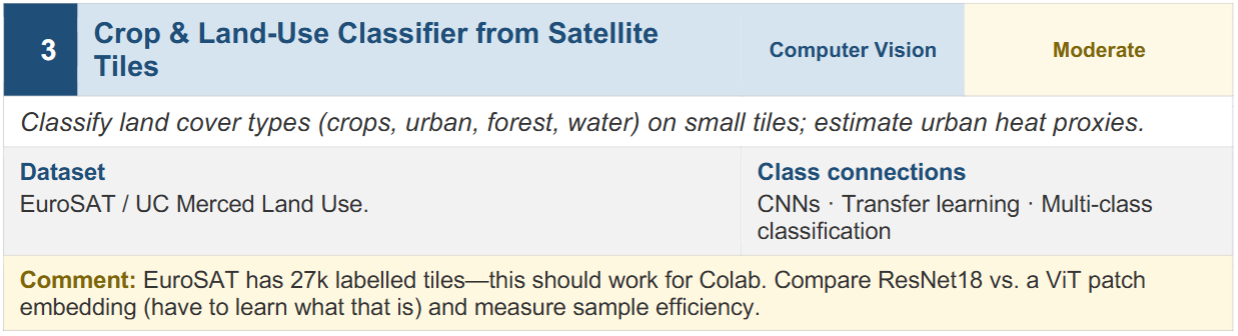

**Ideas to improve predictions (feel free to add any ideas you have here, even if you don't know if it'll help at all):**

*   Try transforming UC Merced Land Use data to have the same classes and same resolution as EuroSAT to get more training data (note, I think the UC data has a different pixel resolution too, like 1m or something, have to check that)
*   Try the 13 channel EuroSAT images instead of the 3 channel RGB images as input (figure out how we can do this, maybe by adding a 13 to 3 channel conv layer to the front of ResNet18?)
*   Give the models the 8 adjacent tiles (or at least their predicted classification) as input alongside the target tile. We'd have to figure out a way of finding the adjacent tiles, maybe there's a pattern to the file names/numbers or some documentation in the original source.
*   Not necessarily improve predictions, but to improve the project we could try increasing the classes we predict somehow, maybe the UC dataset instead or some other method.
*   Instead of predicting all classes at once, predict a broad category first (Water, Vegetation, Urban, Barren), then a second model predicts the specific sub-type.
*   Instead of telling the model "this image is 100% class 7", you tell it "this image is 95% class 7 and 5% distributed among other classes".
*   After training, generate a confusion matrix to see which specific classes the model confuses. This could make the results more credible









**What is Land Use?**

“Land use” is the term used to describe the human use of land. It represents the economic and cultural activities (e.g., agricultural, residential, industrial, mining, and recreational uses) that are practiced at a given place.

Land use differs from land cover in that some uses are not always physically obvious (e.g., land used for producing timber but not harvested for many years and forested land designated as wilderness will both appear as forest-covered, but they have different uses).

https://www.epa.gov/report-environment/land-use

Data Sources
*   Professor Suggested
    *   [EuroSAT](https://github.com/phelber/EuroSAT)
    *   [UC Merced Land Use](https://www.kaggle.com/datasets/abdulhasibuddin/uc-merced-land-use-dataset)
*   Possible Others
    *   [USGS Land Cover](https://www.usgs.gov/centers/eros/science/usgs-eros-archive-land-cover-annual-nlcd-collection-1-land-cover#overview) + [USGS Land Cover Confidence](https://www.usgs.gov/centers/eros/science/usgs-eros-archive-land-cover-annual-nlcd-collection-1-land-cover-confidence#overview)
        *   Note this is land cover, not land use, though could be useful secondary data
    *   [USGS National Agriculture Imagery Program](https://www.usgs.gov/centers/eros/science/usgs-eros-archive-aerial-photography-national-agriculture-imagery-program-naip?qt-science_center_objects=0#overview)
        *   Basically just images of the US during growing seasons, high resolution (<= 1m). Probably one of the more useful datasets, we can probably transform these images into a similar format as the professor suggested datasets.
    *   [Elevation Source Data (3DEP) > LIDAR Point Cloud](https://apps.nationalmap.gov/downloader/)
        *   Ultra-high resolution, raw data. Probably not useful on its own, but maybe we can derive something from it that's useful. Massive dataset, just 1/10 of Austin is ~10 GB and consists of over a billion points.
    *   Other data from the link above that could be useful:
        *   *Structures - National Structures Dataset* > USGS Structures dataset defines where buildings are
        *   *Transportation* > USGS Transportation dataset might be useful for classifying roads or whatever else is in it (not sure exactly what it is).
        *   *Hydrography* > National Hydrography Dataset (NHD)
    *   Collections of Data Sources
        *   https://libguides.mit.edu/gis/land




1. Do we want to define more classes? Fewer? I feel these classes could be expanded quite a bit, though probably only as much as we can create a good training set.
2. We should figure out at what resolution we want to classify land use (10 square meters? 20? 50? 100? Larger?)

**Classes**</br>
UC Merced Land Use
*   Agricultural
*   Airplane
*   Baseball Diamond
*   Beach
*   Buildings
*   Chaparral
*   Dense Residential
*   Forest
*   Freeway
*   Golf Course
*   Harbor
*   Intersection
*   Medium Residential
*   Mobile Home Park
*   Overpass
*   Parking Lot
*   River
*   Runway
*   Sparse Residential
*   Storage Tanks
*   Tennis Court

EuroSAT
*   Annual Crop
*   Forest
*   Herbaceous Vegetation
*   Highway
*   Industrial
*   Pasture
*   Permanent Crop
*   Residential
*   River
*   Sea Lake

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

!cp /content/drive/MyDrive/ECE_460J/EuroSAT_RGB.zip /content/
!unzip -q -o /content/EuroSAT_RGB.zip -d /content/

rgb_eurosat_file_path = '/content/EuroSAT_RGB'
!ls /content/EuroSAT_RGB/

Mounted at /content/drive
AnnualCrop  HerbaceousVegetation  Industrial  PermanentCrop  River
Forest	    Highway		  Pasture     Residential    SeaLake


In [ ]:
import os

drive_path = '/content/drive/MyDrive/ECE_460J/'
if os.path.exists(drive_path):
    print(f"Contents of {drive_path}:")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"Directory not found: {drive_path}")

Contents of /content/drive/MyDrive/ECE_460J/:
Lab3_P1.npz
EuroSAT_RGB.zip


---
# ResNet18 (on RGB EuroSAT data)



In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


In [ ]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [ ]:
from torchsummary import summary
model.to(device)
summary(model, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          36,864
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
       BasicBlock-11           [-1, 64, 16, 16]               0
           Conv2d-12           [-1, 64, 16, 16]          36,864
      BatchNorm2d-13           [-1, 64, 16, 16]             128
             ReLU-14           [-1, 64,

In [ ]:
layer_names = [name for name, _ in model.named_modules()]
for name in layer_names:
    print(name)


conv1
bn1
relu
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.relu
layer1.0.conv2
layer1.0.bn2
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.relu
layer1.1.conv2
layer1.1.bn2
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.relu
layer2.0.conv2
layer2.0.bn2
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.relu
layer2.1.conv2
layer2.1.bn2
layer3
layer3.0
layer3.0.conv1
layer3.0.bn1
layer3.0.relu
layer3.0.conv2
layer3.0.bn2
layer3.0.downsample
layer3.0.downsample.0
layer3.0.downsample.1
layer3.1
layer3.1.conv1
layer3.1.bn1
layer3.1.relu
layer3.1.conv2
layer3.1.bn2
layer4
layer4.0
layer4.0.conv1
layer4.0.bn1
layer4.0.relu
layer4.0.conv2
layer4.0.bn2
layer4.0.downsample
layer4.0.downsample.0
layer4.0.downsample.1
layer4.1
layer4.1.conv1
layer4.1.bn1
layer4.1.relu
layer4.1.conv2
layer4.1.bn2
avgpool
fc


In [ ]:
fc_input_features = model.fc.in_features
model.fc = nn.Linear(fc_input_features, 10)
model = model.to(device)

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(rgb_eurosat_file_path, transform=transform)

generator = torch.Generator().manual_seed(123)
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [0.8, 0.2], generator=generator)

print(len(train_dataset))
print(len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

21600
5400


In [ ]:
print(device)

cuda


In [ ]:
# LABEL SMOOTHING LOSS
class LabelSmoothingCrossEntropy(nn.Module):
    """
    Label Smoothing Cross Entropy Loss
    Instead of [0,0,1,0] for correct class, use [0.025, 0.025, 0.85, 0.025, ...]
    """
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(1)

        # Create smoothed labels: (1 - smoothing) * one_hot + smoothing / n_classes
        with torch.no_grad():
            # Convert target to one-hot
            one_hot = torch.zeros_like(pred)
            one_hot.scatter_(1, target.unsqueeze(1), 1)
            # Apply smoothing
            smoothed_labels = one_hot * (1 - self.smoothing) + (self.smoothing / n_classes)

        # Calculate cross entropy with smoothed labels
        log_prob = torch.nn.functional.log_softmax(pred, dim=1)
        loss = -torch.sum(smoothed_labels * log_prob, dim=1)
        return loss.mean()

Epoch 1/10, Training Loss: 0.9956688954985353, Testing Loss: 0.7880663121447844, Testing Accuracy: 0.9107
Epoch 2/10, Training Loss: 0.7897117485308788, Testing Loss: 0.7625316654934603, Testing Accuracy: 0.9170
Epoch 3/10, Training Loss: 0.7683611261774097, Testing Loss: 0.7441968083381653, Testing Accuracy: 0.9248
Epoch 4/10, Training Loss: 0.7536007832493302, Testing Loss: 0.7373632501153385, Testing Accuracy: 0.9315
Epoch 5/10, Training Loss: 0.7486149174927255, Testing Loss: 0.7369867794653948, Testing Accuracy: 0.9306
Epoch 6/10, Training Loss: 0.7416296070496712, Testing Loss: 0.7376041748944451, Testing Accuracy: 0.9270
Epoch 7/10, Training Loss: 0.7406651321247485, Testing Loss: 0.7281488621936125, Testing Accuracy: 0.9328
Epoch 8/10, Training Loss: 0.7205926209864532, Testing Loss: 0.7210301069652333, Testing Accuracy: 0.9376
Epoch 9/10, Training Loss: 0.7186710388350064, Testing Loss: 0.7209096417707556, Testing Accuracy: 0.9367
Epoch 10/10, Training Loss: 0.7182958096089448

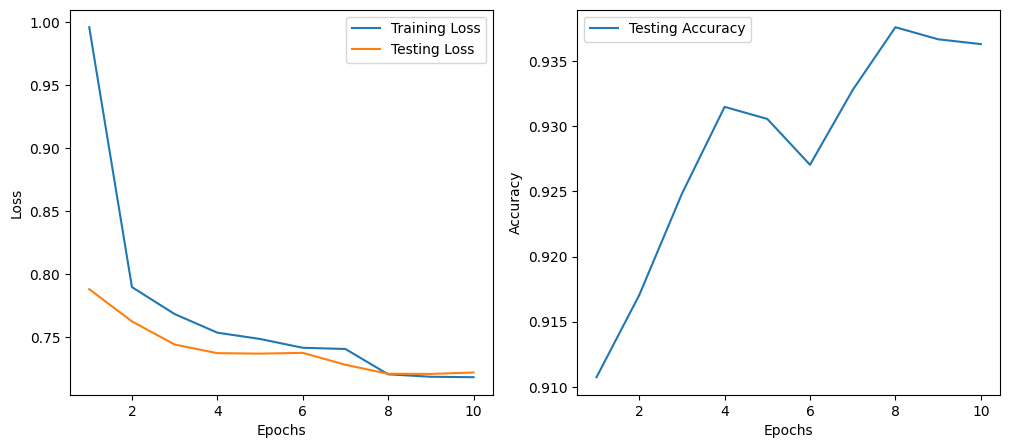

Epoch 1/5, Training Loss: 0.6623993896873746, Testing Loss: 0.6077813393929425, Testing Accuracy: 0.9783
Epoch 2/5, Training Loss: 0.5651941706795665, Testing Loss: 0.5861018026576322, Testing Accuracy: 0.9817
Epoch 3/5, Training Loss: 0.5415747036948007, Testing Loss: 0.5741635175312266, Testing Accuracy: 0.9843
Epoch 4/5, Training Loss: 0.5291526010755957, Testing Loss: 0.5677552559796502, Testing Accuracy: 0.9843
Epoch 5/5, Training Loss: 0.5238259103171219, Testing Loss: 0.5654688659836264, Testing Accuracy: 0.9843
Loaded the best model from epoch 3 with Testing Accuracy: 0.9843


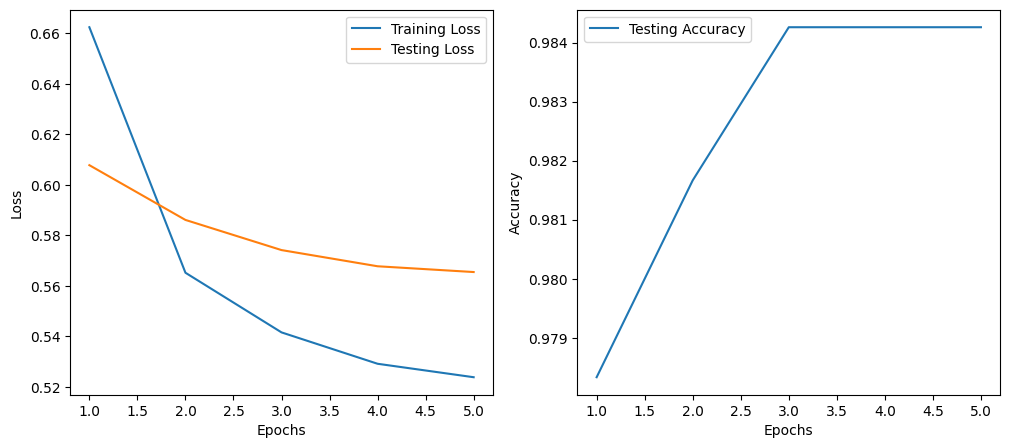

Training Accuracy: 100.00%
Testing Accuracy: 98.43%


In [ ]:
from torch import optim
import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt


def train(model, train_loader, test_loader, optimizer, epochs):
    # criterion
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

    # scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    return train_losses, test_losses, test_accuracies, best_accuracy


def evaluate(model, data_loader, device):
    model.eval()  # Set model to evaluate mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


# freeze all layers
for param in model.parameters():
    param.requires_grad = False


# unfreeze the last layer
for param in model.fc.parameters():
    param.requires_grad = True


torch.manual_seed(123)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 10
train(model, train_loader, test_loader, optimizer, epochs)


# unfreeze all layers and train the whole network
for param in model.parameters():
    param.requires_grad = True


# redefine optimizer to include all parameters
optimizer = optim.Adam(model.parameters(), lr=0.0001)


# train
optimizer = optim.Adam(model.parameters(), lr=0.00005)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)


testaccuracy = evaluate(model, test_loader, device)
trainaccuracy = evaluate(model, train_loader, device)
print(f"Training Accuracy: {trainaccuracy * 100:.2f}%")
print(f"Testing Accuracy: {testaccuracy * 100:.2f}%")

---
# ViT Patch Embedding

## ViT Patch Embedding & Sample Efficiency Comparison

This section extends the project's core requirement of comparing ResNet18 against a
ViT patch embedding by adding a **sample efficiency analysis**. Rather than only
comparing both models at full data, we train each on increasing fractions of the
training set (1%, 5%, 10%, 25%, 50%, 100%) to see how performance scales with data.

**Why this matters:** ResNet18's convolutional inductive bias (locality, translation
equivariance) helps it generalize from less data, while ViT has no such prior and
relies more on data volume. Comparing the two across data fractions reveals which
architecture is more practical when labeled satellite data is limited — a realistic
constraint in remote sensing.

**Setup:**
- Both models start from ImageNet-pretrained weights and are fine-tuned end-to-end
  with the same protocol (Adam, no scheduler, identical epochs per fraction).
- ViT uses `vit_small_patch16_224` from `timm` (~22M params, comparable to ResNet18's
  ~11M; we use the smaller ViT variant to keep training time tractable on Colab).
- Learning rates differ (ResNet 1e-4, ViT 5e-5) because ViT is more sensitive to
  large updates on small datasets.
- Smaller fractions get more epochs to allow convergence.
- A confusion matrix on 100% data identifies which classes each model confuses
  (e.g., River vs SeaLake, AnnualCrop vs PermanentCrop).

**Expected outcome:** ResNet should lead at low data fractions; the gap should
narrow or invert as data increases. If results deviate, the deviation itself is
worth discussing in the report.

  epoch 1/8: test acc = 0.9780
  epoch 2/8: test acc = 0.9796
  epoch 3/8: test acc = 0.9833
  epoch 4/8: test acc = 0.9859
  epoch 5/8: test acc = 0.9689
  epoch 6/8: test acc = 0.9802
  epoch 7/8: test acc = 0.9841
  epoch 8/8: test acc = 0.9843

ViT full-data best acc: 0.9859

=== 1% (216 samples) ===
[ResNet18]
  epoch 1/15: test acc = 0.3867
  epoch 2/15: test acc = 0.6231
  epoch 3/15: test acc = 0.7328
  epoch 4/15: test acc = 0.7669
  epoch 5/15: test acc = 0.8026
  epoch 6/15: test acc = 0.8315
  epoch 7/15: test acc = 0.8528
  epoch 8/15: test acc = 0.8589
  epoch 9/15: test acc = 0.8635
  epoch 10/15: test acc = 0.8687
  epoch 11/15: test acc = 0.8654
  epoch 12/15: test acc = 0.8661
  epoch 13/15: test acc = 0.8654
  epoch 14/15: test acc = 0.8665
  epoch 15/15: test acc = 0.8639
[ViT-Small]
  epoch 1/15: test acc = 0.5922
  epoch 2/15: test acc = 0.7794
  epoch 3/15: test acc = 0.8394
  epoch 4/15: test acc = 0.8622
  epoch 5/15: test acc = 0.8798
  epoch 6/15: test acc = 

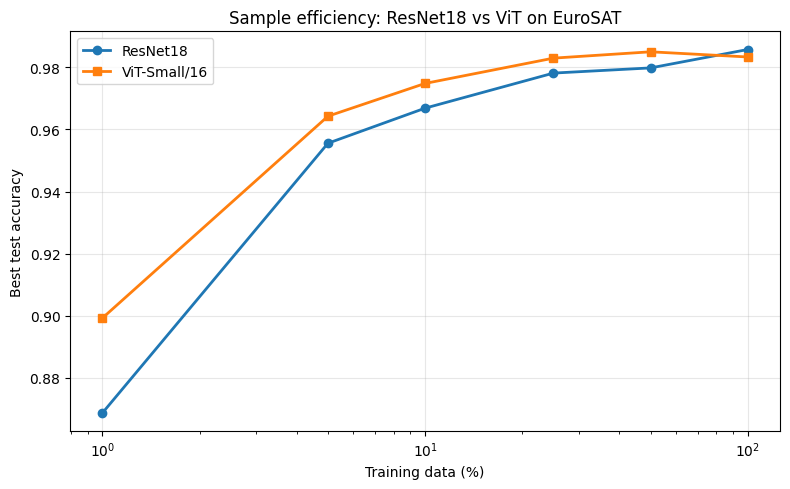


  Fraction   ResNet18  ViT-Small        Δ
        1%     0.8687     0.8993  +0.0306
        5%     0.9556     0.9643  +0.0087
       10%     0.9669     0.9748  +0.0080
       25%     0.9781     0.9830  +0.0048
       50%     0.9798     0.9850  +0.0052
      100%     0.9857     0.9833  -0.0024


In [ ]:
#Siyoung Kim
!pip install timm -q
import timm
import numpy as np
from torch.utils.data import Subset, DataLoader

def make_resnet():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 10)
    return m.to(device)

def make_vit():
    m = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=10)
    return m.to(device)

def get_subset_loader(dataset, fraction, batch_size=64, seed=42):
    n = int(len(dataset) * fraction)
    g = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=g)[:n].tolist()
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=2)

def train_and_eval(model, train_loader, test_loader, epochs=8, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
        # eval
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                _, pred = torch.max(model(images), 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        acc = correct / total
        best_acc = max(best_acc, acc)
        print(f"  epoch {epoch+1}/{epochs}: test acc = {acc:.4f}")
    return best_acc

torch.manual_seed(123)
vit = make_vit()
full_train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
vit_full_acc = train_and_eval(vit, full_train_loader, test_loader, epochs=8, lr=5e-5)
print(f"\nViT full-data best acc: {vit_full_acc:.4f}")\

fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
results = {'resnet': {}, 'vit': {}}

#Sweep
for frac in fractions:
    n_samples = int(len(train_dataset) * frac)
    print(f"\n=== {frac*100:.0f}% ({n_samples} samples) ===")
    sub_loader = get_subset_loader(train_dataset, frac, seed=42)

    # for smaller data more epochs so that converges
    epochs = 15 if frac <= 0.05 else (10 if frac <= 0.25 else 8)

    print("[ResNet18]")
    torch.manual_seed(123)
    resnet = make_resnet()
    results['resnet'][frac] = train_and_eval(resnet, sub_loader, test_loader,
                                             epochs=epochs, lr=1e-4)

    print("[ViT-Small]")
    torch.manual_seed(123)
    vit = make_vit()
    results['vit'][frac] = train_and_eval(vit, sub_loader, test_loader,
                                          epochs=epochs, lr=5e-5)

    print(f"  → ResNet: {results['resnet'][frac]:.4f} | ViT: {results['vit'][frac]:.4f}")

    import matplotlib.pyplot as plt

fracs = sorted(results['resnet'].keys())
plt.figure(figsize=(8, 5))
plt.plot([f*100 for f in fracs], [results['resnet'][f] for f in fracs],
         'o-', label='ResNet18', linewidth=2)
plt.plot([f*100 for f in fracs], [results['vit'][f] for f in fracs],
         's-', label='ViT-Small/16', linewidth=2)
plt.xscale('log')
plt.xlabel('Training data (%)')
plt.ylabel('Best test accuracy')
plt.title('Sample efficiency: ResNet18 vs ViT on EuroSAT')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print as a table
print(f"\n{'Fraction':>10} {'ResNet18':>10} {'ViT-Small':>10} {'Δ':>8}")
for f in fracs:
    r, v = results['resnet'][f], results['vit'][f]
    print(f"{f*100:>9.0f}% {r:>10.4f} {v:>10.4f} {v-r:>+8.4f}")



In [ ]:
import json

# Save in Drive
with open('/content/drive/MyDrive/ECE_460J/sweep_results.json', 'w') as f:
    json.dump({
        'resnet': {str(k): v for k, v in results['resnet'].items()},
        'vit': {str(k): v for k, v in results['vit'].items()}
    }, f, indent=2)

# print out in the termnial so that we can copy
print("=== RESULTS ===")
print(results)
print("\nSaved to Drive!")


=== RESULTS ===
{'resnet': {0.01: 0.8687037037037038, 0.05: 0.9555555555555556, 0.1: 0.9668518518518519, 0.25: 0.9781481481481481, 0.5: 0.9798148148148148, 1.0: 0.9857407407407407}, 'vit': {0.01: 0.8992592592592593, 0.05: 0.9642592592592593, 0.1: 0.9748148148148148, 0.25: 0.9829629629629629, 0.5: 0.985, 1.0: 0.9833333333333333}}

Saved to Drive!


In [ ]:
torch.save(resnet.state_dict(), '/content/drive/MyDrive/ECE_460J/resnet_full.pth')
torch.save(vit.state_dict(), '/content/drive/MyDrive/ECE_460J/vit_full.pth')
print("Models saved!")

Models saved!


### Sample Efficiency: ResNet18 vs ViT-Small

We trained both architectures on increasing fractions of the EuroSAT training set
(1%, 5%, 10%, 25%, 50%, 100%) using identical protocols (Adam optimizer,
ImageNet-pretrained weights, end-to-end fine-tuning). Each fraction was evaluated
on the full held-out test set.

| Fraction | ResNet18 | ViT-Small | Δ (ViT − ResNet) |
|----------|----------|-----------|------------------|
| 1%   | 0.8687 | 0.8993 | **+3.06%p** |
| 5%   | 0.9556 | 0.9643 | +0.87%p |
| 10%  | 0.9669 | 0.9748 | +0.79%p |
| 25%  | 0.9781 | 0.9830 | +0.48%p |
| 50%  | 0.9798 | 0.9850 | +0.52%p |
| 100% | **0.9857** | 0.9833 | −0.24%p |

**Key observations:**

1. **ViT-Small consistently outperforms ResNet18 from 1% to 50% data**, with the
largest gap at 1% (+3.06%p, 216 training samples).

2. **The advantage shrinks monotonically with more data** — from +3.06%p at 1%
to roughly parity at 50%.

3. **At 100% data, ResNet18 marginally surpasses ViT-Small** (+0.24%p). With enough
labeled data, the convolutional inductive bias (locality, translation equivariance)
becomes competitive with — or slightly better than — the more flexible attention-based
representation.

**Interpretation.** The conventional finding (Dosovitskiy et al., 2020) is that ViT
underperforms CNNs in low-data regimes due to its lack of inductive bias. Our results
show the opposite trend on EuroSAT: a strongly ImageNet-pretrained ViT-Small actually
*benefits* from low-data fine-tuning relative to ResNet18, likely because (a) its
larger pretrained representation transfers more information per labeled example, and
(b) global self-attention is well-suited to satellite tiles where context across the
whole image matters. This has practical implications for remote sensing, where labeled
data is often expensive to obtain.

###Confusion Matrix

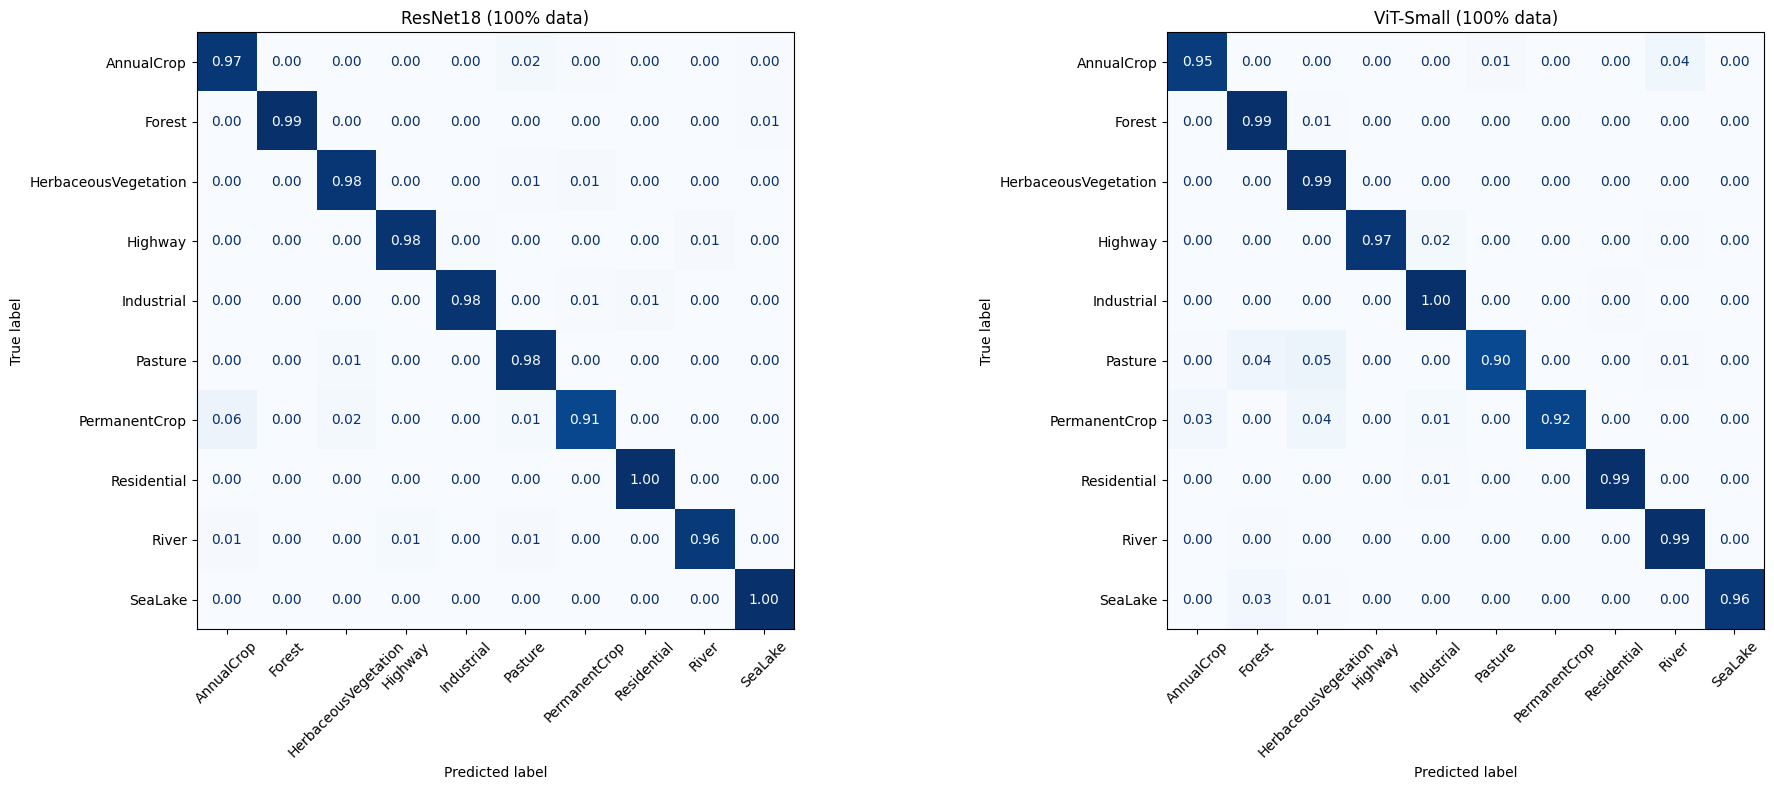

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, p = torch.max(model(images), 1)
            preds.extend(p.cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(labels_all), np.array(preds)

class_names = full_dataset.classes

# Using the final two models trained on 100% of the data (ResNet and ViT from the last iteration of the sweep)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, model, name in [(axes[0], resnet, 'ResNet18'), (axes[1], vit, 'ViT-Small')]:
    y_true, y_pred = get_predictions(model, test_loader)
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False, values_format='.2f')
    ax.set_title(f'{name} (100% data)')
plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

Both models achieve high overall accuracy (>98%), but the per-class confusion
patterns reveal complementary strengths and weaknesses.

**Shared weakness — vegetation classes are inherently ambiguous in RGB.**
Both ResNet18 and ViT-Small confuse `PermanentCrop` with `AnnualCrop` and
`HerbaceousVegetation` (91–92% accuracy on PermanentCrop). This is a data
limitation rather than a model limitation: distinguishing crop types from a
single-snapshot RGB tile is hard without temporal or multispectral information.

**Where the two models diverge — `Pasture`:**
- ResNet18: **98%** accuracy on Pasture
- ViT-Small: **90%** accuracy, with 4% confused as Forest and 5% as HerbaceousVegetation

This is the largest per-class gap between the two architectures, and it points to
a known trade-off: ViT's 16×16 patch tokenization can lose fine-grained local
texture, which is exactly what distinguishes grass from forest canopy from herbaceous
cover. CNNs capture this through local convolutions naturally.

**Takeaway.** Despite ViT-Small's overall sample-efficiency advantage at low data
fractions, it underperforms ResNet18 on a subset of texture-driven classes at full
data. This complementary profile suggests an ensemble of the two could outperform
either alone — a direction we leave for future work.

---
# Additional Research to try to achieve higher accuracy:
##EuroSAT Multispectral (13-Channel ResNet18)

### Why this matters
The RGB baseline only uses 3 of the 13 Sentinel-2 bands. The extra bands include Near-Infrared (great for vegetation), Short-Wave Infrared (distinguishes urban/soil/moisture), and Red Edge bands. Classes like AnnualCrop vs PermanentCrop and River vs SeaLake should benefit most from this extra information.

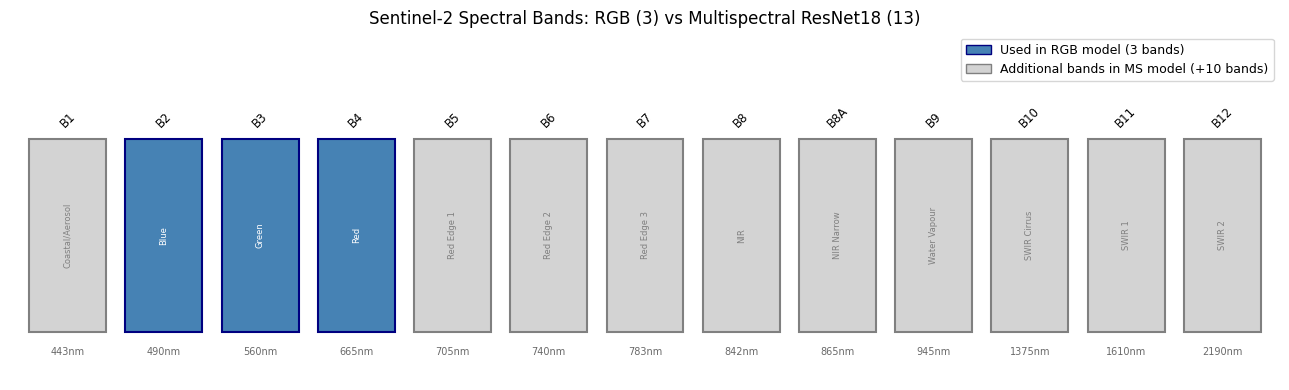

In [ ]:
# Spectral bands visualizer: extra info the EuroSAT MS model gets vs RGB EuroSAT
bands = [
    ('B1',  'Coastal/Aerosol', 443,  False),
    ('B2',  'Blue',            490,  True),
    ('B3',  'Green',           560,  True),
    ('B4',  'Red',             665,  True),
    ('B5',  'Red Edge 1',      705,  False),
    ('B6',  'Red Edge 2',      740,  False),
    ('B7',  'Red Edge 3',      783,  False),
    ('B8',  'NIR',             842,  False),
    ('B8A', 'NIR Narrow',      865,  False),
    ('B9',  'Water Vapour',    945,  False),
    ('B10', 'SWIR Cirrus',     1375, False),
    ('B11', 'SWIR 1',          1610, False),
    ('B12', 'SWIR 2',          2190, False),
]

fig, ax = plt.subplots(figsize=(13, 4))
for i, (band, name, wl, is_rgb) in enumerate(bands):
    color = 'steelblue' if is_rgb else 'lightgray'
    edge  = 'navy'      if is_rgb else 'gray'
    ax.bar(i, 1, color=color, edgecolor=edge, linewidth=1.5)
    ax.text(i, 1.06, band,  ha='center', fontsize=8.5, rotation=45)
    ax.text(i, -0.12, f'{wl}nm', ha='center', fontsize=7, color='dimgray')
    ax.text(i, 0.5,  name,  ha='center', va='center', fontsize=6,
            rotation=90, color='white' if is_rgb else 'gray')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='steelblue', edgecolor='navy',
          label='Used in RGB model (3 bands)'),
    Patch(facecolor='lightgray', edgecolor='gray',
          label='Additional bands in MS model (+10 bands)')
], loc='upper right', fontsize=9)

ax.set_xlim(-0.6, 12.6)
ax.set_ylim(-0.25, 1.55)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Sentinel-2 Spectral Bands: RGB (3) vs Multispectral ResNet18 (13)', fontsize=12)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
!unzip /content/EuroSAT_MS.zip -d /content/EuroSAT_MS

Streaming output truncated to the last 5000 lines.
  inflating: /content/EuroSAT_MS/EuroSAT_MS/PermanentCrop/PermanentCrop_1106.tif  
  inflating: /content/EuroSAT_MS/__MACOSX/EuroSAT_MS/PermanentCrop/._PermanentCrop_1106.tif  
  inflating: /content/EuroSAT_MS/EuroSAT_MS/PermanentCrop/PermanentCrop_1112.tif  
  inflating: /content/EuroSAT_MS/__MACOSX/EuroSAT_MS/PermanentCrop/._PermanentCrop_1112.tif  
  inflating: /content/EuroSAT_MS/EuroSAT_MS/PermanentCrop/PermanentCrop_209.tif  
  inflating: /content/EuroSAT_MS/__MACOSX/EuroSAT_MS/PermanentCrop/._PermanentCrop_209.tif  
  inflating: /content/EuroSAT_MS/EuroSAT_MS/PermanentCrop/PermanentCrop_1674.tif  
  inflating: /content/EuroSAT_MS/__MACOSX/EuroSAT_MS/PermanentCrop/._PermanentCrop_1674.tif  
  inflating: /content/EuroSAT_MS/EuroSAT_MS/PermanentCrop/PermanentCrop_2194.tif  
  inflating: /content/EuroSAT_MS/__MACOSX/EuroSAT_MS/PermanentCrop/._PermanentCrop_2194.tif  
  inflating: /content/EuroSAT_MS/EuroSAT_MS/PermanentCrop/Permanen

In [ ]:
eurosat_ms_path = '/content/EuroSAT_MS/EuroSAT_MS'
print('EuroSAT MS classes:', sorted(os.listdir(eurosat_ms_path)))

EuroSAT MS classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## EuroSAT MS Custom Dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, Dataset
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import rasterio
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class EuroSATMS(Dataset):
    """
    Custom Dataset for EuroSAT All-Bands (13-channel GeoTIFF).
    Expects folder structure:
        EuroSAT_MS/
            AnnualCrop/  *.tif
            Forest/      *.tif
            ...
    """
    # Per-band mean and std computed over the full EuroSAT MS dataset
    BAND_MEANS = [
        1354.40, 1118.24, 1042.92,  947.62, 1199.47, 1999.79,
        2369.22, 2296.82,  732.08,   12.09, 1819.01, 1118.92, 2594.14
    ]
    BAND_STDS = [
         245.71,  333.00,  395.09,  593.75,  566.40,  861.18,
        1086.63, 1117.98,  404.91,    4.77, 1002.58,  761.30, 1231.58
    ]

    def __init__(self, root):
        self.root = Path(root)
        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            for tif in sorted((self.root / cls).glob('*.tif')):
                self.samples.append((str(tif), self.class_to_idx[cls]))

        self.means = torch.tensor(self.BAND_MEANS, dtype=torch.float32).view(13, 1, 1)
        self.stds  = torch.tensor(self.BAND_STDS,  dtype=torch.float32).view(13, 1, 1)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)  # (13, 64, 64)
        img = torch.from_numpy(img)
        img = (img - self.means) / self.stds
        # Resize 64x64 → 224x224 for ResNet
        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=(224, 224),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        return img, label


ms_dataset = EuroSATMS(eurosat_ms_path)
print(f'Total images : {len(ms_dataset)}')
print(f'Classes ({len(ms_dataset.classes)}): {ms_dataset.classes}')
img, label = ms_dataset[0]
print(f'Sample shape : {img.shape}')  # should be (13, 224, 224)

Using device: cuda
Total images : 27000
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Sample shape : torch.Size([13, 224, 224])


## Train/Test Split

In [ ]:
generator = torch.Generator().manual_seed(123)
ms_train, ms_test = torch.utils.data.random_split(
    ms_dataset, [0.8, 0.2], generator=generator
)
print(f'MS train: {len(ms_train)} | MS test: {len(ms_test)}')

ms_train_loader = DataLoader(ms_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
ms_test_loader  = DataLoader(ms_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

MS train: 21600 | MS test: 5400


## Build the 13-Channel ResNet18

ResNet18 normally expects 3-channel RGB input. We replace the very first conv layer to accept 13 channels:
- The 3 RGB slots get the pretrained ImageNet weights copied in directly
- The remaining 10 slots start at the mean of the RGB weights (better than random noise)

In [ ]:
def make_resnet18_ms(num_classes=10, in_channels=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    pretrained_w = model.conv1.weight.data.clone()  # (64, 3, 7, 7)

    new_conv = nn.Conv2d(
        in_channels, 64,
        kernel_size=7, stride=2, padding=3, bias=False
    )
    with torch.no_grad():
        new_conv.weight[:, :3, :, :] = pretrained_w
        mean_w = pretrained_w.mean(dim=1, keepdim=True)  # (64, 1, 7, 7)
        for c in range(3, in_channels):
            new_conv.weight[:, c, :, :] = mean_w.squeeze(1)

    model.conv1 = new_conv
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


torch.manual_seed(123)
ms_model = make_resnet18_ms(num_classes=10, in_channels=13)
print('13-channel ResNet18 ready.')
dummy = torch.randn(2, 13, 224, 224).to(device)
print(f'Output shape: {ms_model(dummy).shape}')  # should be (2, 10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


13-channel ResNet18 ready.
Output shape: torch.Size([2, 10])


## Training Utilities

In [ ]:
def train_model(model, train_loader, test_loader, epochs=10, lr=1e-4,
                scheduler_step=7, scheduler_gamma=0.1, label='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=scheduler_step, gamma=scheduler_gamma
    )
    train_losses, test_losses, test_accs = [], [], []
    best_acc     = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    best_epoch   = 1

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        t_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                t_loss += criterion(outputs, labels).item()
                _, pred = torch.max(outputs, 1)
                total   += labels.size(0)
                correct += (pred == labels).sum().item()
        test_losses.append(t_loss / len(test_loader))
        acc = correct / total
        test_accs.append(acc)

        if acc > best_acc:
            best_acc     = acc
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch   = epoch + 1

        print(f'[{label}] Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Test Loss: {test_losses[-1]:.4f} | '
              f'Test Acc: {acc:.4f}')

    model.load_state_dict(best_weights)
    print(f'\nBest {label} → epoch {best_epoch}, accuracy {best_acc:.4f}')
    return train_losses, test_losses, test_accs, best_acc


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, pred = torch.max(model(images), 1)
            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(labels.tolist())
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return acc, all_preds, all_labels


def plot_curves(train_losses, test_losses, test_accs, title):
    epochs_range = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13)
    axes[0].plot(epochs_range, train_losses, label='Train Loss')
    axes[0].plot(epochs_range, test_losses,  label='Test Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves'); axes[0].legend()
    axes[1].plot(epochs_range, test_accs, color='green', label='Test Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Test Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(true_labels, pred_labels, class_names, title):
    cm   = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(12, 11))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    per_class = cm.diagonal() / cm.sum(axis=1)
    print('\nPer-class accuracy:')
    for cls, a in sorted(zip(class_names, per_class), key=lambda x: x[1]):
        bar = '█' * int(a * 20)
        print(f'  {cls:<25} {a*100:5.1f}%  {bar}')


print('Utility functions ready.')

Utility functions ready.


## Train EuroSAT MS ResNet18

In [ ]:
torch.manual_seed(123)
ms_model = make_resnet18_ms(num_classes=10, in_channels=13)

ms_train_losses, ms_test_losses, ms_test_accs, ms_best_acc = train_model(
    ms_model, ms_train_loader, ms_test_loader,
    epochs=15, lr=1e-4, scheduler_step=7, scheduler_gamma=0.1,
    label='EuroSAT-MS'
)

[EuroSAT-MS] Epoch 1/15 | Train Loss: 0.1823 | Test Loss: 0.1276 | Test Acc: 0.9607
[EuroSAT-MS] Epoch 2/15 | Train Loss: 0.0554 | Test Loss: 0.0876 | Test Acc: 0.9730
[EuroSAT-MS] Epoch 3/15 | Train Loss: 0.0376 | Test Loss: 0.0562 | Test Acc: 0.9831
[EuroSAT-MS] Epoch 4/15 | Train Loss: 0.0280 | Test Loss: 0.0851 | Test Acc: 0.9746
[EuroSAT-MS] Epoch 5/15 | Train Loss: 0.0201 | Test Loss: 0.0786 | Test Acc: 0.9767
[EuroSAT-MS] Epoch 6/15 | Train Loss: 0.0214 | Test Loss: 0.0559 | Test Acc: 0.9850
[EuroSAT-MS] Epoch 7/15 | Train Loss: 0.0191 | Test Loss: 0.1073 | Test Acc: 0.9694
[EuroSAT-MS] Epoch 8/15 | Train Loss: 0.0076 | Test Loss: 0.0350 | Test Acc: 0.9909
[EuroSAT-MS] Epoch 9/15 | Train Loss: 0.0031 | Test Loss: 0.0377 | Test Acc: 0.9898
[EuroSAT-MS] Epoch 10/15 | Train Loss: 0.0022 | Test Loss: 0.0348 | Test Acc: 0.9900
[EuroSAT-MS] Epoch 11/15 | Train Loss: 0.0022 | Test Loss: 0.0364 | Test Acc: 0.9894
[EuroSAT-MS] Epoch 12/15 | Train Loss: 0.0018 | Test Loss: 0.0347 | Test A

## EuroSAT MS Results

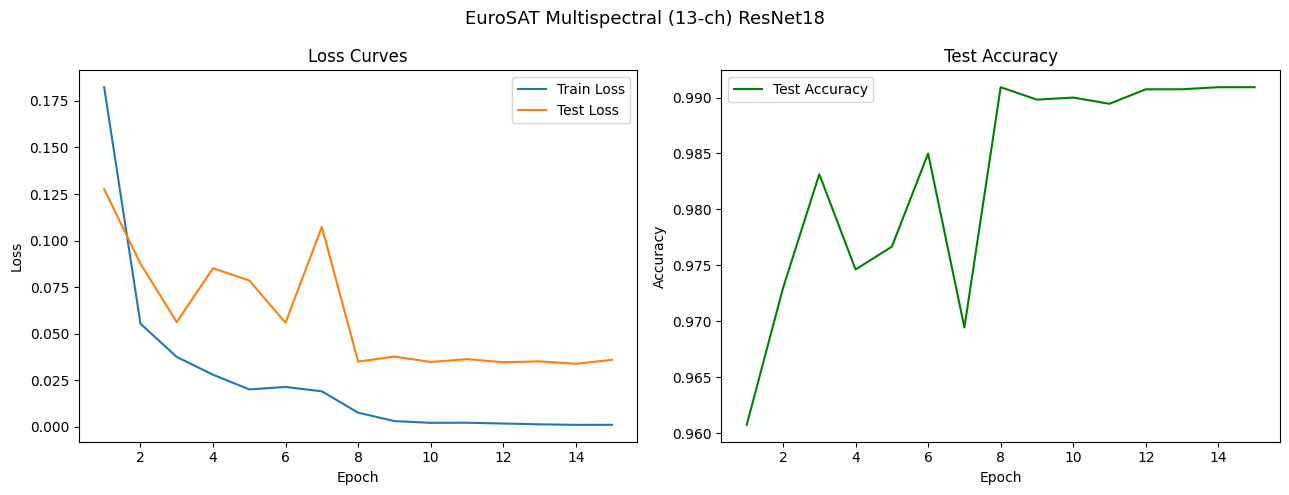

EuroSAT MS — Train Acc: 100.00%  |  Best Test Acc: 99.09%


In [ ]:
plot_curves(
    ms_train_losses, ms_test_losses, ms_test_accs,
    'EuroSAT Multispectral (13-ch) ResNet18'
)
ms_train_acc, _, _ = evaluate(ms_model, ms_train_loader)
print(f'EuroSAT MS — Train Acc: {ms_train_acc*100:.2f}%  |  Best Test Acc: {ms_best_acc*100:.2f}%')

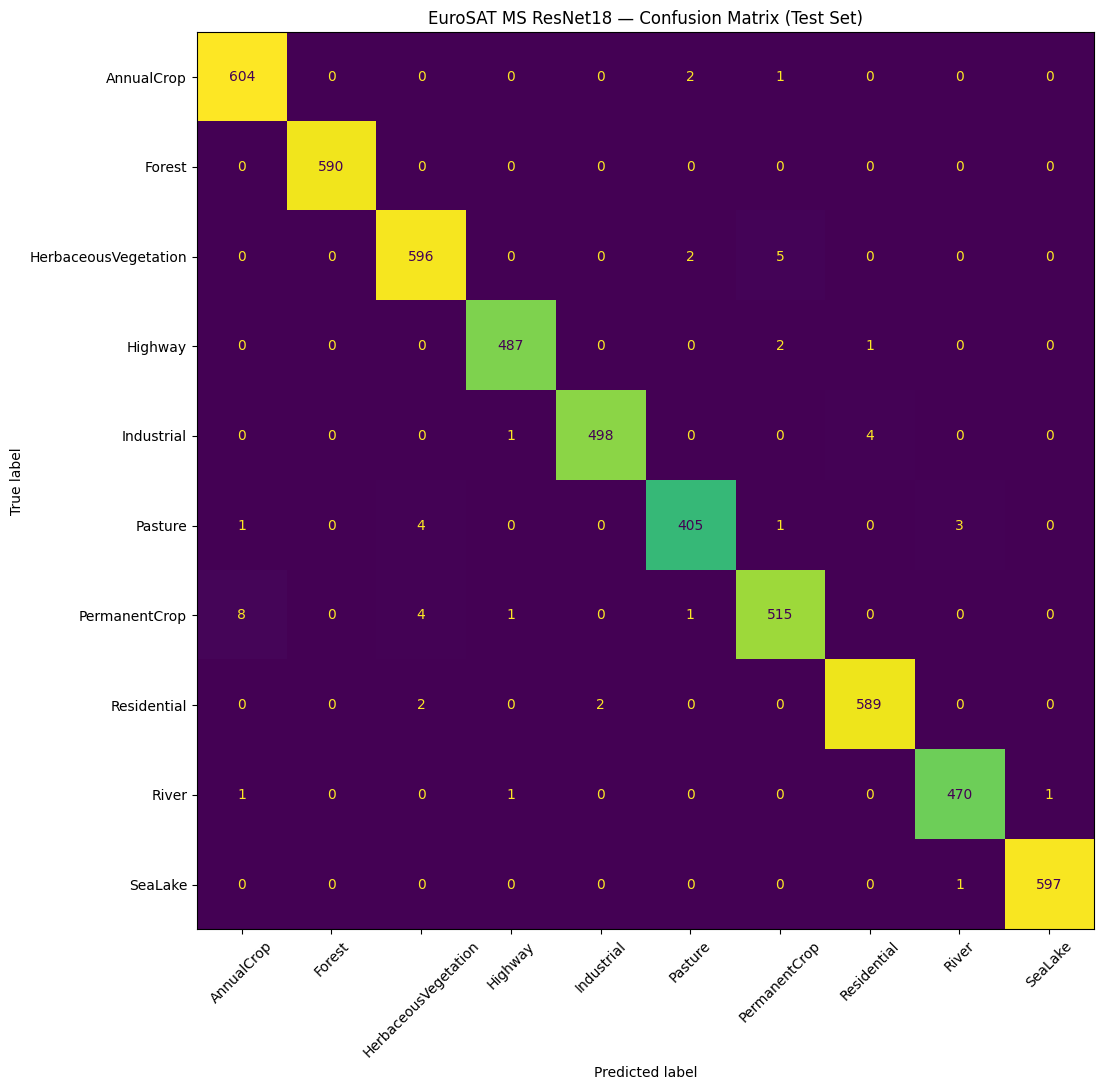


Per-class accuracy:
  PermanentCrop              97.4%  ███████████████████
  Pasture                    97.8%  ███████████████████
  HerbaceousVegetation       98.8%  ███████████████████
  Industrial                 99.0%  ███████████████████
  Residential                99.3%  ███████████████████
  River                      99.4%  ███████████████████
  Highway                    99.4%  ███████████████████
  AnnualCrop                 99.5%  ███████████████████
  SeaLake                    99.8%  ███████████████████
  Forest                    100.0%  ████████████████████


In [ ]:
_, ms_preds, ms_true = evaluate(ms_model, ms_test_loader)
plot_confusion_matrix(
    ms_true, ms_preds,
    ms_dataset.classes,
    'EuroSAT MS ResNet18 — Confusion Matrix (Test Set)'
)

---
# UC Merced Land Use (21-Class ResNet18)

### Why this matters
EuroSAT has 10 broad classes at 10m/pixel satellite resolution. UC Merced has **21 much more specific classes** (e.g. `baseball_diamond`, `mobile_home_park`, `storage_tanks`) at ~0.3m/pixel aerial resolution.

| | EuroSAT RGB | UC Merced |
|---|---|---|
| Total images | 27,000 | 2,100 |
| Per class | 2,000–3,000 | 100 |
| Image size | 64×64 px | 256×256 px |
| Classes | 10 | 21 |
| Source | Sentinel-2 satellite | USGS aerial |

Because the dataset is ~13x smaller we use stronger augmentation and the same two-phase training approach as teammates.

In [ ]:
!unzip /content/UCMerced_LandUse.zip -d /content/UCMerced_LandUse/

Archive:  /content/UCMerced_LandUse.zip
   creating: /content/UCMerced_LandUse/UCMerced_LandUse/
  inflating: /content/UCMerced_LandUse/__MACOSX/._UCMerced_LandUse  
   creating: /content/UCMerced_LandUse/UCMerced_LandUse/Images/
  inflating: /content/UCMerced_LandUse/__MACOSX/UCMerced_LandUse/._Images  
  inflating: /content/UCMerced_LandUse/UCMerced_LandUse/readme.txt.bak  
  inflating: /content/UCMerced_LandUse/__MACOSX/UCMerced_LandUse/._readme.txt.bak  
  inflating: /content/UCMerced_LandUse/UCMerced_LandUse/readme.txt  
  inflating: /content/UCMerced_LandUse/__MACOSX/UCMerced_LandUse/._readme.txt  
   creating: /content/UCMerced_LandUse/UCMerced_LandUse/Images/forest/
  inflating: /content/UCMerced_LandUse/__MACOSX/UCMerced_LandUse/Images/._forest  
   creating: /content/UCMerced_LandUse/UCMerced_LandUse/Images/buildings/
  inflating: /content/UCMerced_LandUse/__MACOSX/UCMerced_LandUse/Images/._buildings  
   creating: /content/UCMerced_LandUse/UCMerced_LandUse/Images/river/
  in

In [ ]:
import os
uc_path = '/content/UCMerced_LandUse/UCMerced_LandUse/Images'
print('UC Merced classes: ', sorted(os.listdir(uc_path)))

UC Merced classes:  ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


## UC Merced Dataset & DataLoaders

In [ ]:
uc_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

uc_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset twice — same images, different transforms for train vs test
uc_full_train = datasets.ImageFolder(uc_path, transform=uc_train_transform)
uc_full_test  = datasets.ImageFolder(uc_path, transform=uc_test_transform)

uc_classes = uc_full_train.classes
print(f'UC Merced: {len(uc_full_train)} images, {len(uc_classes)} classes')
print(f'Classes: {uc_classes}')

# 80/20 split using same indices for both
generator = torch.Generator().manual_seed(123)
n       = len(uc_full_train)
indices = torch.randperm(n, generator=generator).tolist()
split   = int(0.8 * n)
train_idx, test_idx = indices[:split], indices[split:]

uc_train_dataset = Subset(uc_full_train, train_idx)
uc_test_dataset  = Subset(uc_full_test,  test_idx)
print(f'Train: {len(uc_train_dataset)} | Test: {len(uc_test_dataset)}')

uc_train_loader = DataLoader(uc_train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
uc_test_loader  = DataLoader(uc_test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

UC Merced: 2100 images, 21 classes
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Train: 1680 | Test: 420


## Build ResNet18 for UC Merced (21 classes)

In [ ]:
def make_resnet18_uc(num_classes=21):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

torch.manual_seed(123)
uc_model = make_resnet18_uc(num_classes=21)
print('UC Merced ResNet18 ready (21 classes).')
dummy = torch.randn(2, 3, 224, 224).to(device)
print(f'Output shape: {uc_model(dummy).shape}')  # should be (2, 21)

UC Merced ResNet18 ready (21 classes).
Output shape: torch.Size([2, 21])


## Train UC Merced — Phase 1 (FC layer only)

=== Phase 1: FC layer only ===
[UC-Merced Phase1] Epoch 1/10 | Train Loss: 2.1922 | Test Loss: 1.3202 | Test Acc: 0.7405
[UC-Merced Phase1] Epoch 2/10 | Train Loss: 1.0659 | Test Loss: 0.7961 | Test Acc: 0.8286
[UC-Merced Phase1] Epoch 3/10 | Train Loss: 0.7245 | Test Loss: 0.6068 | Test Acc: 0.8405
[UC-Merced Phase1] Epoch 4/10 | Train Loss: 0.5846 | Test Loss: 0.5172 | Test Acc: 0.8524
[UC-Merced Phase1] Epoch 5/10 | Train Loss: 0.4905 | Test Loss: 0.4377 | Test Acc: 0.8905
[UC-Merced Phase1] Epoch 6/10 | Train Loss: 0.4189 | Test Loss: 0.3855 | Test Acc: 0.9143
[UC-Merced Phase1] Epoch 7/10 | Train Loss: 0.3868 | Test Loss: 0.3556 | Test Acc: 0.9214
[UC-Merced Phase1] Epoch 8/10 | Train Loss: 0.3686 | Test Loss: 0.3412 | Test Acc: 0.9238
[UC-Merced Phase1] Epoch 9/10 | Train Loss: 0.3442 | Test Loss: 0.3379 | Test Acc: 0.9071
[UC-Merced Phase1] Epoch 10/10 | Train Loss: 0.3309 | Test Loss: 0.3116 | Test Acc: 0.9238

Best UC-Merced Phase1 → epoch 8, accuracy 0.9238


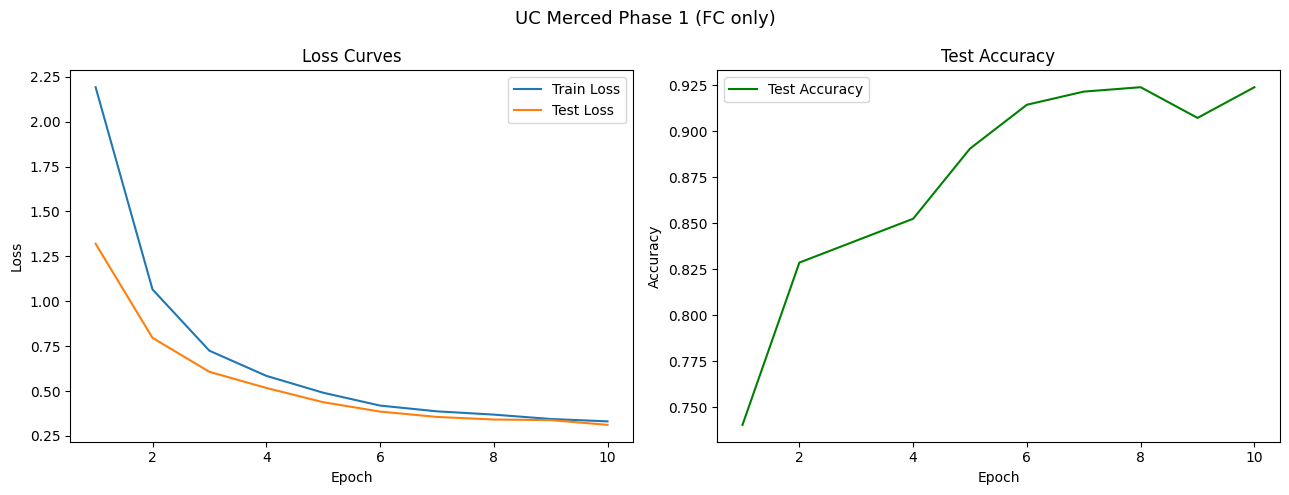

In [ ]:
for param in uc_model.parameters():
    param.requires_grad = False
for param in uc_model.fc.parameters():
    param.requires_grad = True

print('=== Phase 1: FC layer only ===')
uc_p1_train_losses, uc_p1_test_losses, uc_p1_accs, uc_p1_best = train_model(
    uc_model, uc_train_loader, uc_test_loader,
    epochs=10, lr=1e-3, scheduler_step=5, scheduler_gamma=0.5,
    label='UC-Merced Phase1'
)
plot_curves(uc_p1_train_losses, uc_p1_test_losses, uc_p1_accs,
            'UC Merced Phase 1 (FC only)')

## Train UC Merced — Phase 2 (Full fine-tuning)

In [ ]:
for param in uc_model.parameters():
    param.requires_grad = True

print('=== Phase 2: Full fine-tuning ===')
uc_train_losses, uc_test_losses, uc_test_accs, uc_best_acc = train_model(
    uc_model, uc_train_loader, uc_test_loader,
    epochs=20, lr=5e-5, scheduler_step=8, scheduler_gamma=0.2,
    label='UC-Merced Phase2'
)

=== Phase 2: Full fine-tuning ===
[UC-Merced Phase2] Epoch 1/20 | Train Loss: 0.2520 | Test Loss: 0.1627 | Test Acc: 0.9548
[UC-Merced Phase2] Epoch 2/20 | Train Loss: 0.1086 | Test Loss: 0.1329 | Test Acc: 0.9643
[UC-Merced Phase2] Epoch 3/20 | Train Loss: 0.0802 | Test Loss: 0.1195 | Test Acc: 0.9595
[UC-Merced Phase2] Epoch 4/20 | Train Loss: 0.0488 | Test Loss: 0.1046 | Test Acc: 0.9667
[UC-Merced Phase2] Epoch 5/20 | Train Loss: 0.0398 | Test Loss: 0.0803 | Test Acc: 0.9690
[UC-Merced Phase2] Epoch 6/20 | Train Loss: 0.0252 | Test Loss: 0.0733 | Test Acc: 0.9738
[UC-Merced Phase2] Epoch 7/20 | Train Loss: 0.0216 | Test Loss: 0.0638 | Test Acc: 0.9786
[UC-Merced Phase2] Epoch 8/20 | Train Loss: 0.0206 | Test Loss: 0.0716 | Test Acc: 0.9786
[UC-Merced Phase2] Epoch 9/20 | Train Loss: 0.0199 | Test Loss: 0.0681 | Test Acc: 0.9786
[UC-Merced Phase2] Epoch 10/20 | Train Loss: 0.0196 | Test Loss: 0.0610 | Test Acc: 0.9762
[UC-Merced Phase2] Epoch 11/20 | Train Loss: 0.0135 | Test Loss: 

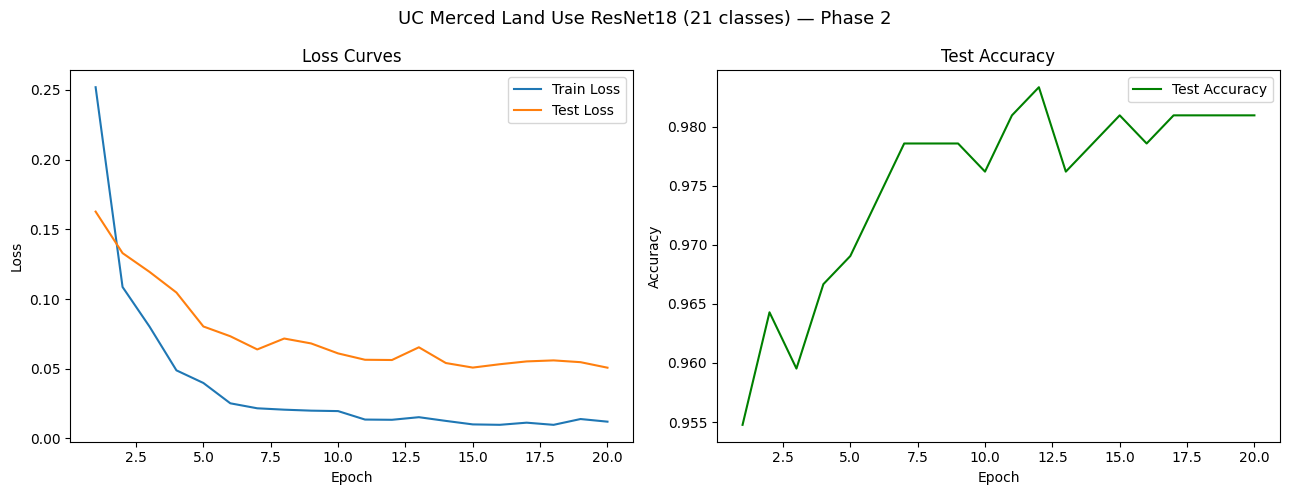

UC Merced — Train Acc: 100.00%  |  Best Test Acc: 98.33%


In [ ]:
plot_curves(
    uc_train_losses, uc_test_losses, uc_test_accs,
    'UC Merced Land Use ResNet18 (21 classes) — Phase 2'
)
uc_train_acc, _, _ = evaluate(uc_model, uc_train_loader)
print(f'UC Merced — Train Acc: {uc_train_acc*100:.2f}%  |  Best Test Acc: {uc_best_acc*100:.2f}%')

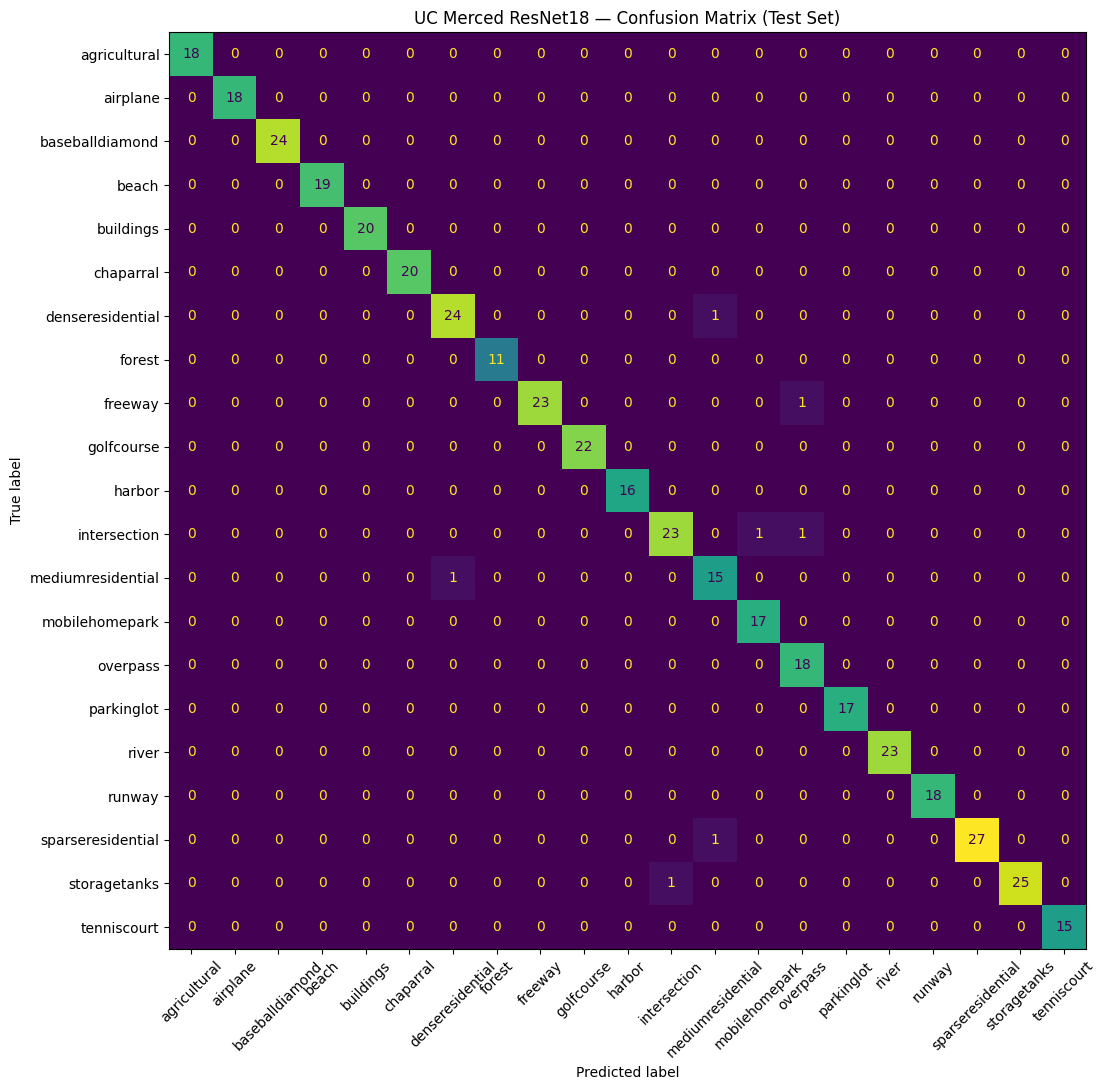


Per-class accuracy:
  intersection               92.0%  ██████████████████
  mediumresidential          93.8%  ██████████████████
  freeway                    95.8%  ███████████████████
  denseresidential           96.0%  ███████████████████
  storagetanks               96.2%  ███████████████████
  sparseresidential          96.4%  ███████████████████
  agricultural              100.0%  ████████████████████
  airplane                  100.0%  ████████████████████
  baseballdiamond           100.0%  ████████████████████
  beach                     100.0%  ████████████████████
  buildings                 100.0%  ████████████████████
  chaparral                 100.0%  ████████████████████
  forest                    100.0%  ████████████████████
  golfcourse                100.0%  ████████████████████
  harbor                    100.0%  ████████████████████
  mobilehomepark            100.0%  ████████████████████
  overpass                  100.0%  ████████████████████
  parkinglot      

In [ ]:
_, uc_preds, uc_true = evaluate(uc_model, uc_test_loader)
plot_confusion_matrix(
    uc_true, uc_preds,
    uc_classes,
    'UC Merced ResNet18 — Confusion Matrix (Test Set)'
)

In [ ]:
rgb_baseline_acc = 0.9813  # teammates' best test accuracy

print('=' * 58)
print(f'{"Model":<38} {"Test Accuracy":>12}')
print('=' * 58)
print(f'{"EuroSAT RGB ResNet18":<38} {rgb_baseline_acc*100:>11.2f}%')
print(f'{"EuroSAT MS 13-ch ResNet18 ":<38} {ms_best_acc*100:>11.2f}%')
print(f'{"UC Merced 21-class ResNet18 ":<38} {uc_best_acc*100:>11.2f}%')
print('=' * 58)

delta = ms_best_acc - rgb_baseline_acc
sign  = '+' if delta >= 0 else ''
print(f'\nMultispectral improvement over RGB baseline: {sign}{delta*100:.2f}%')
print(f'\nNote: UC Merced uses 21 finer-grained classes vs EuroSAT RGB\'s 10,')
print(f'      and has ~13x fewer training images (1,680 vs 21,600),')
print(f'      so a direct accuracy comparison is not meaningful.')

Model                                  Test Accuracy
EuroSAT RGB ResNet18                         98.13%
EuroSAT MS 13-ch ResNet18                    99.09%
UC Merced 21-class ResNet18                  98.33%

Multispectral improvement over RGB baseline: +0.96%

Note: UC Merced uses 21 finer-grained classes vs EuroSAT RGB's 10,
      and has ~13x fewer training images (1,680 vs 21,600),
      so a direct accuracy comparison is not meaningful.


Everything from this point down may not work in Colab, it was run on a local machine so small changes may need to be made if you want to run it in Colab.

Preprocessing Data

In [ ]:
import rasterio
from rasterio.warp import transform as warp_transform
import geopandas as gpd
from shapely.geometry import Polygon
import json
import glob
import os


def get_direction(center, neighbor):
    dx = neighbor.x - center.x
    dy = neighbor.y - center.y

    tol = 0.0001

    if abs(dx) < tol:
        if dy > tol: return "N"
        if dy < -tol: return "S"
    elif abs(dy) < tol:
        if dx > tol: return "E"
        if dx < -tol: return "W"
    elif dx > tol and dy > tol:
        return "NE"
    elif dx < -tol and dy > tol:
        return "NW"
    elif dx > tol and dy < -tol:
        return "SE"
    elif dx < -tol and dy < -tol:
        return "SW"

    return "UNKNOWN"


def build_spatial_cache(image_directory, output_file="spatial_cache.json"):
    print(f"Scanning for .tif files in {image_directory}...")

    data = []
    file_pattern = os.path.join(image_directory, "**/*.tif")

    for filepath in glob.glob(file_pattern, recursive=True):
        filename = os.path.basename(filepath)

        try:
            with rasterio.open(filepath) as src:
                orig_crs = src.crs
                transform = src.transform
                width = src.width
                height = src.height

                # Format: (col, row) which corresponds to (x, y)
                pixel_corners = [
                    (0, 0),  # Top-Left
                    (width, 0),  # Top-Right
                    (width, height),  # Bottom-Right
                    (0, height)  # Bottom-Left
                ]

                native_xs = []
                native_ys = []
                for col, row in pixel_corners:
                    x, y = transform * (col, row)
                    native_xs.append(x)
                    native_ys.append(y)

                lons, lats = warp_transform(orig_crs, 'EPSG:4326', native_xs, native_ys)
                corners_latlon = [(lons[i], lats[i]) for i in range(4)]
                geom = Polygon(corners_latlon)

                data.append({
                    "filename": filename,
                    "geometry": geom,
                    "corners": corners_latlon
                })
        except Exception as e:
            print(f"Error reading {filename}: {e}")

    if not data:
        print("No valid .tif files found.")
        return

    print(f"Successfully loaded {len(data)} images. Building normalized spatial index...")

    gdf = gpd.GeoDataFrame(data, geometry="geometry", crs="EPSG:4326")
    cache = {}

    print("Calculating neighbors...")
    for idx, row in gdf.iterrows():
        search_area = row.geometry.buffer(0.0002)

        neighbors_idx = gdf.sindex.query(search_area, predicate="intersects")

        neighbor_dict = {}
        for n_idx in neighbors_idx:
            if n_idx == idx:
                continue

            neighbor_row = gdf.iloc[n_idx]

            direction = get_direction(row.geometry.centroid, neighbor_row.geometry.centroid)

            if direction != "UNKNOWN":
                neighbor_dict[direction] = neighbor_row["filename"].replace('.tif', '.jpg')

        cache[row["filename"].replace('.tif', '.jpg')] = {
            "corners_latlon": row["corners"],
            "neighbors": neighbor_dict
        }

    with open(output_file, "w") as f:
        json.dump(cache, f, indent=4)

    print(f"Cache saved to {output_file}")


if __name__ == "__main__":
    IMAGE_DIR = "./EuroSAT_MS"
    build_spatial_cache(IMAGE_DIR)


Fetching Adjacent Images

In [ ]:
import pystac_client
import planetary_computer
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer, Geod
from shapely.geometry import Polygon
import numpy as np
import math
import json
import os
import threading
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed


def create_eurosat_patch(corners_latlon, output_filepath):
    """
    Creates a 64x64 pixel RGB JPEG from Sentinel-2 data.
    Returns True if successful, False if no image could be generated.
    """
    poly = Polygon(corners_latlon)
    center_lon, center_lat = poly.centroid.x, poly.centroid.y

    try:
        catalog = pystac_client.Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1",
            modifier=planetary_computer.sign_inplace,
        )

        search = catalog.search(
            collections=["sentinel-2-l2a"],
            intersects={"type": "Point", "coordinates": [center_lon, center_lat]},
            query={"eo:cloud_cover": {"lt": 20}},
            datetime="2017-01-01/2017-12-31",
            sortby=[{"field": "eo:cloud_cover", "direction": "asc"}]
        )

        items = list(search.items())
        if not items:
            return False

        summer_items = [item for item in items if item.datetime.month in [5, 6, 7, 8]]
        item = summer_items[0] if summer_items else items[0]

        assets = ["B04", "B03", "B02"]
        rgb_bands = []

        first_band_href = item.assets[assets[0]].href

        with rasterio.open(first_band_href) as src:
            transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
            center_x, center_y = transformer.transform(center_lon, center_lat)

            minx, maxx = center_x - 320, center_x + 320
            miny, maxy = center_y - 320, center_y + 320

            window = from_bounds(minx, miny, maxx, maxy, src.transform)
            window = rasterio.windows.Window(round(window.col_off), round(window.row_off), 64, 64)

        for band_name in assets:
            href = item.assets[band_name].href
            with rasterio.open(href) as src:
                band_data = src.read(1, window=window).astype(np.float32)
                band_data = np.clip(band_data, 0, 2750)
                band_data = (band_data / 2750.0) * 254.0 + 1
                band_data = np.clip(band_data, 0, 255).astype(np.uint8)
                rgb_bands.append(band_data)

        rgb_array = np.stack(rgb_bands, axis=-1)
        img = Image.fromarray(rgb_array, 'RGB')
        img.save(output_filepath, quality=100)
        return True


    except Exception as e:
        error_msg = str(e).lower()

        if "429" in error_msg or "rate limit" in error_msg or "too many requests" in error_msg:
            print(f"\nWarning: Rate limited.")

        elif "502" in error_msg or "503" in error_msg or "504" in error_msg:
            print(f"\nWarning: Server error (50x error).")

        return False


def shift_corners(corners_latlon, direction):
    g = Geod(ellps='WGS84')
    azimuths = {
        "N": 0, "NE": 45, "E": 90, "SE": 135,
        "S": 180, "SW": 225, "W": 270, "NW": 315
    }
    az = azimuths[direction]
    distance = 650 if len(direction) == 1 else 650 * math.sqrt(2)

    shifted_corners = []
    for lon, lat in corners_latlon:
        new_lon, new_lat, _back_azimuth = g.fwd(lon, lat, az, distance)
        shifted_corners.append((new_lon, new_lat))
    return shifted_corners


def download_worker(task):
    target_tile, direction, new_corners, output_filepath, new_filename = task

    if os.path.exists(output_filepath):
        return (target_tile, direction, new_filename, True)

    success = create_eurosat_patch(new_corners, output_filepath)
    return (target_tile, direction, new_filename, success)


def generate_all_missing_neighbors_parallel(cache_file, output_folder, max_workers=10):
    os.makedirs(output_folder, exist_ok=True)

    print(f"Loading spatial cache from {cache_file}...")
    with open(cache_file, 'r') as f:
        cache = json.load(f)

    all_dirs = ["N", "S", "E", "W", "NE", "NW", "SE", "SW"]
    tasks = []

    original_tiles = list(cache.keys())
    print(f"Found {len(original_tiles)} base tiles in cache. Queuing tasks...")

    # 1. Build the master list of all tasks
    for target_tile in original_tiles:
        if "_generated_" in target_tile:
            continue

        tile_data = cache[target_tile]
        existing_neighbors = tile_data.get("neighbors", {})
        missing_dirs = [d for d in all_dirs if d not in existing_neighbors]

        if not missing_dirs:
            continue

        base_corners = tile_data["corners_latlon"]
        base_name = target_tile.replace('.jpg', '').replace('.tif', '')

        for d in missing_dirs:
            new_filename = f"{base_name}_generated_{d}.jpg"
            output_filepath = os.path.join(output_folder, new_filename)
            new_corners = shift_corners(base_corners, d)

            tasks.append((target_tile, d, new_corners, output_filepath, new_filename))

    total_tasks = len(tasks)
    print(f"Discovered {total_tasks} missing adjacent tiles to generate.")
    print(f"Starting ThreadPool with {max_workers} concurrent workers...")

    cache_lock = threading.Lock()
    completed_count = 0
    successful_count = 0
    SAVE_INTERVAL = 1000

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_task = {executor.submit(download_worker, task): task for task in tasks}

        for future in as_completed(future_to_task):
            target_tile, direction, new_filename, success = future.result()
            completed_count += 1

            if success:
                successful_count += 1

                with cache_lock:
                    cache[target_tile]["neighbors"][direction] = new_filename

                    if successful_count % SAVE_INTERVAL == 0:
                        temp_file = cache_file + ".tmp"
                        with open(temp_file, "w") as f:
                            json.dump(cache, f, indent=4)
                        os.replace(temp_file, cache_file)

            if completed_count % 500 == 0 or completed_count == total_tasks:
                print(
                    f"Progress: [{completed_count}/{total_tasks}] tasks processed. ({successful_count} successfully saved)")

    print("All threads finished. Performing final cache save...")
    temp_file = cache_file + ".tmp"
    with open(temp_file, "w") as f:
        json.dump(cache, f, indent=4)
    os.replace(temp_file, cache_file)

    print(f"Finished! Successfully generated {successful_count} new adjacent tiles.")


if __name__ == "__main__":
    CACHE_PATH = "spatial_cache.json"
    OUTPUT_DIR = "EuroSAT_RGB_Unclassified_Adjacents"

    generate_all_missing_neighbors_parallel(CACHE_PATH, OUTPUT_DIR, max_workers=80)

Fetching Temporal Images

In [ ]:
import pystac_client
import planetary_computer
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer
from shapely.geometry import Polygon
import numpy as np
import json
import os
import threading
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed


def create_seasonal_patch(corners_latlon, date_range, output_filepath):
    poly = Polygon(corners_latlon)
    center_lon, center_lat = poly.centroid.x, poly.centroid.y

    try:
        catalog = pystac_client.Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1",
            modifier=planetary_computer.sign_inplace,
        )

        search = catalog.search(
            collections=["sentinel-2-l2a"],
            intersects={"type": "Point", "coordinates": [center_lon, center_lat]},
            query={"eo:cloud_cover": {"lt": 25}},
            datetime=date_range,
            sortby=[{"field": "eo:cloud_cover", "direction": "asc"}]
        )

        items = list(search.items())
        if not items:
            return False

        item = items[0]

        assets = ["B04", "B03", "B02"]
        rgb_bands = []

        first_band_href = item.assets[assets[0]].href

        with rasterio.open(first_band_href) as src:
            transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
            center_x, center_y = transformer.transform(center_lon, center_lat)

            minx, maxx = center_x - 320, center_x + 320
            miny, maxy = center_y - 320, center_y + 320

            window = from_bounds(minx, miny, maxx, maxy, src.transform)
            window = rasterio.windows.Window(round(window.col_off), round(window.row_off), 64, 64)

        for band_name in assets:
            href = item.assets[band_name].href
            with rasterio.open(href) as src:
                band_data = src.read(1, window=window).astype(np.float32)
                band_data = np.clip(band_data, 0, 2750)
                band_data = (band_data / 2750.0) * 254.0 + 1
                band_data = np.clip(band_data, 0, 255).astype(np.uint8)
                rgb_bands.append(band_data)

        rgb_array = np.stack(rgb_bands, axis=-1)
        img = Image.fromarray(rgb_array, 'RGB')
        img.save(output_filepath, quality=100)
        return True

    except Exception as e:
        return False


def download_season_worker(task):
    corners, date_range, output_filepath = task

    if os.path.exists(output_filepath):
        return True

    return create_seasonal_patch(corners, date_range, output_filepath)


def generate_seasonal_dataset(cache_file, output_base_folder, max_workers=10):
    print(f"Loading spatial cache from {cache_file} (Read-Only)...")
    with open(cache_file, 'r') as f:
        cache = json.load(f)

    seasons = {
        "Spring": "2017-03-01/2017-05-31",
        "Summer": "2017-06-01/2017-08-31",
        "Fall": "2017-09-01/2017-11-30",
        "Winter": "2017-12-01/2018-02-28"
    }

    tasks = []
    original_tiles = [k for k in cache.keys() if "_generated_" not in k]

    print(f"Found {len(original_tiles)} base tiles. Building directory structure and queuing tasks...")

    for target_tile in original_tiles:
        class_name = target_tile.split('_')[0]

        tile_name_clean = target_tile.replace('.jpg', '').replace('.tif', '')

        target_dir = os.path.join(output_base_folder, class_name, tile_name_clean)
        os.makedirs(target_dir, exist_ok=True)

        corners = cache[target_tile]["corners_latlon"]

        for season_name, date_range in seasons.items():
            output_filepath = os.path.join(target_dir, f"{season_name}.jpg")
            tasks.append((corners, date_range, output_filepath))

    total_tasks = len(tasks)
    print(f"Discovered {total_tasks} seasonal images to download.")
    print(f"Starting ThreadPool with {max_workers} concurrent workers...")

    completed_count = 0
    successful_count = 0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_task = {executor.submit(download_season_worker, task): task for task in tasks}

        for future in as_completed(future_to_task):
            success = future.result()
            completed_count += 1
            if success:
                successful_count += 1

            if completed_count % 50 == 0 or completed_count == total_tasks:
                print(f"Progress: [{completed_count}/{total_tasks}] downloaded. ({successful_count} successful)")

    print(f"Finished! Successfully populated {successful_count} seasonal patches.")


if __name__ == "__main__":
    CACHE_PATH = "spatial_cache.json"
    OUTPUT_DIR = "EuroSAT_RGB_Seasons"

    generate_seasonal_dataset(CACHE_PATH, OUTPUT_DIR, max_workers=80)


Dual Branch ResNet18

In [ ]:
import os
import json
import copy
import rasterio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class EuroSAT_Fusion_Dataset(Dataset):
    def __init__(self, cache_file, ms_dir, rgb_dir, seasons_dir, adjacents_dir, transform_wide=None):
        self.ms_dir = ms_dir
        self.rgb_dir = rgb_dir
        self.seasons_dir = seasons_dir
        self.adjacents_dir = adjacents_dir
        self.transform_wide = transform_wide

        with open(cache_file, 'r') as f:
            full_cache = json.load(f)
        self.tiles = [k for k in full_cache.keys() if "_generated_" not in k]
        self.cache = full_cache

        self.classes = sorted(["AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
                               "Industrial", "Pasture", "PermanentCrop", "Residential",
                               "River", "SeaLake"])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.grid_map = {
            'NW': (0, 0), 'N': (64, 0), 'NE': (128, 0),
            'W': (0, 64), 'C': (64, 64), 'E': (128, 64),
            'SW': (0, 128), 'S': (64, 128), 'SE': (128, 128)
        }

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        target_tile = self.tiles[idx]
        class_name = target_tile.split('_')[0]
        tile_clean = target_tile.replace('.jpg', '').replace('.tif', '')
        label = self.class_to_idx[class_name]

        # Branch 1: Deep tensor
        deep_channels = []
        ms_path = os.path.join(self.ms_dir, class_name, f"{tile_clean}.tif")
        with rasterio.open(ms_path) as src:
            ms_data = src.read().astype(np.float32) / 10000.0
            deep_channels.append(torch.tensor(ms_data))

        for season in ["Spring", "Summer", "Fall", "Winter"]:
            season_path = os.path.join(self.seasons_dir, class_name, tile_clean, f"{season}.jpg")
            if os.path.exists(season_path):
                img_pil = Image.open(season_path).convert("RGB").resize((64, 64))
                img = np.array(img_pil).astype(np.float32) / 255.0
            else:
                img = np.zeros((64, 64, 3), dtype=np.float32)

            img = np.transpose(img, (2, 0, 1))
            deep_channels.append(torch.tensor(img))

        x_deep = torch.cat(deep_channels, dim=0)

        # Branch 2: Wide tensor
        canvas = Image.new('RGB', (192, 192), (0, 0, 0))

        center_path = os.path.join(self.rgb_dir, class_name, f"{tile_clean}.jpg")
        if os.path.exists(center_path):
            center_img = Image.open(center_path).convert("RGB").resize((64, 64))
            canvas.paste(center_img, self.grid_map['C'])

        neighbors = self.cache[target_tile].get("neighbors", {})
        for direction, filename in neighbors.items():
            adj_path = os.path.join(self.adjacents_dir, filename)
            if os.path.exists(adj_path):
                adj_img = Image.open(adj_path).convert("RGB").resize((64, 64))
                canvas.paste(adj_img, self.grid_map[direction])

        if self.transform_wide:
            x_wide = self.transform_wide(canvas)
        else:
            x_wide = transforms.ToTensor()(canvas)

        return x_deep, x_wide, label


class DualBranchResNet(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super(DualBranchResNet, self).__init__()

        pretrained_b1 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.branch1 = pretrained_b1
        self.branch1.conv1 = nn.Conv2d(25, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.branch1.fc = nn.Identity()

        pretrained_b2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.branch2 = pretrained_b2
        self.branch2.fc = nn.Identity()

        self.fusion = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x_deep, x_wide):
        emb1 = self.branch1(x_deep)
        emb2 = self.branch2(x_wide)
        fused = torch.cat((emb1, emb2), dim=1)
        out = self.fusion(fused)
        return out


def train_model(model, train_loader, test_loader, optimizer, scheduler, criterion, epochs):
    best_accuracy = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x_deep, x_wide, labels in train_loader:
            x_deep, x_wide, labels = x_deep.to(device), x_wide.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(x_deep, x_wide)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if scheduler:
            scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x_deep, x_wide, labels in test_loader:
                x_deep, x_wide, labels = x_deep.to(device), x_wide.to(device), labels.to(device)
                outputs = model(x_deep, x_wide)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_accuracy = correct / total

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(
            f"  Epoch {epoch + 1}/{epochs} | Train Loss: {total_loss / len(train_loader):.4f} | Test Acc: {epoch_accuracy:.4f}")

    model.load_state_dict(best_model_wts)
    print(f"  --> Restoring best weights from Epoch {best_epoch} (Acc: {best_accuracy:.4f})")
    return best_accuracy


if __name__ == '__main__':
    print("Initializing Data Loaders for Final Champion Run...")

    # Static Transform for Test Set
    transform_static = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Flips Only Transform for Train Set
    transform_flips = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    full_train_dataset = EuroSAT_Fusion_Dataset(
        cache_file="spatial_cache.json", ms_dir="EuroSAT_MS", rgb_dir="EuroSAT_RGB",
        seasons_dir="EuroSAT_RGB_Seasons", adjacents_dir="EuroSAT_RGB_Unclassified_Adjacents",
        transform_wide=transform_flips
    )

    full_test_dataset = EuroSAT_Fusion_Dataset(
        cache_file="spatial_cache.json", ms_dir="EuroSAT_MS", rgb_dir="EuroSAT_RGB",
        seasons_dir="EuroSAT_RGB_Seasons", adjacents_dir="EuroSAT_RGB_Unclassified_Adjacents",
        transform_wide=transform_static
    )

    print("Applying 80/20 Train/Test Split...")
    generator = torch.Generator().manual_seed(123)
    train_subset, test_subs = torch.utils.data.random_split(full_train_dataset, [0.8, 0.2], generator=generator)

    generator = torch.Generator().manual_seed(123)
    _, test_subset = torch.utils.data.random_split(full_test_dataset, [0.8, 0.2], generator=generator)
    # _, test_subset = torch.utils.data.random_split(test_subset, [0.90, 0.10], generator=generator)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=4)

    # Initialize model and loss
    model = DualBranchResNet(dropout_rate=0.5).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Phase 1
    print("\nPhase 1 (10 Epochs)")
    for param in model.parameters(): param.requires_grad = False
    for param in model.branch1.conv1.parameters(): param.requires_grad = True
    for param in model.fusion.parameters(): param.requires_grad = True

    opt_p1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    train_model(model, train_loader, test_loader, opt_p1, None, criterion, epochs=10)

    # Phase 2
    print("\nPhase 2 (15 Epochs)")
    for param in model.parameters(): param.requires_grad = True

    opt_p2 = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
    sched_p2 = optim.lr_scheduler.StepLR(opt_p2, step_size=5, gamma=0.1)

    best_acc = train_model(model, train_loader, test_loader, opt_p2, sched_p2, criterion, epochs=15)

    # Save the model
    acc_string = str(int(best_acc * 10000)).zfill(4)
    save_name = f"EuroSAT_ResNet_8020Split_{acc_string}.pth"
    torch.save(model.state_dict(), save_name)

    print(f"\n{'=' * 50}")
    print(f"Final Result: {best_acc * 100:.2f}%")
    print(f"Model successfully saved to: {save_name}")
    print(f"{'=' * 50}")


Dual Branch ConvNeXT

In [ ]:
import os
import json
import copy
import rasterio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class EuroSAT_Fusion_Dataset(Dataset):
    def __init__(self, cache_file, ms_dir, rgb_dir, seasons_dir, adjacents_dir, transform_wide=None):
        self.ms_dir = ms_dir
        self.rgb_dir = rgb_dir
        self.seasons_dir = seasons_dir
        self.adjacents_dir = adjacents_dir
        self.transform_wide = transform_wide

        with open(cache_file, 'r') as f:
            full_cache = json.load(f)
        self.tiles = [k for k in full_cache.keys() if "_generated_" not in k]
        self.cache = full_cache

        self.classes = sorted(["AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
                               "Industrial", "Pasture", "PermanentCrop", "Residential",
                               "River", "SeaLake"])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.grid_map = {
            'NW': (0, 0), 'N': (64, 0), 'NE': (128, 0),
            'W': (0, 64), 'C': (64, 64), 'E': (128, 64),
            'SW': (0, 128), 'S': (64, 128), 'SE': (128, 128)
        }

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        target_tile = self.tiles[idx]
        class_name = target_tile.split('_')[0]
        tile_clean = target_tile.replace('.jpg', '').replace('.tif', '')
        label = self.class_to_idx[class_name]

        # Branch 1
        deep_channels = []
        ms_path = os.path.join(self.ms_dir, class_name, f"{tile_clean}.tif")
        with rasterio.open(ms_path) as src:
            ms_data = src.read().astype(np.float32) / 10000.0
            deep_channels.append(torch.tensor(ms_data))

        for season in ["Spring", "Summer", "Fall", "Winter"]:
            season_path = os.path.join(self.seasons_dir, class_name, tile_clean, f"{season}.jpg")
            if os.path.exists(season_path):
                img_pil = Image.open(season_path).convert("RGB").resize((64, 64))
                img = np.array(img_pil).astype(np.float32) / 255.0
            else:
                img = np.zeros((64, 64, 3), dtype=np.float32)

            img = np.transpose(img, (2, 0, 1))
            deep_channels.append(torch.tensor(img))

        x_deep = torch.cat(deep_channels, dim=0)

        # Branch 2
        canvas = Image.new('RGB', (192, 192), (0, 0, 0))

        center_path = os.path.join(self.rgb_dir, class_name, f"{tile_clean}.jpg")
        if os.path.exists(center_path):
            center_img = Image.open(center_path).convert("RGB").resize((64, 64))
            canvas.paste(center_img, self.grid_map['C'])

        neighbors = self.cache[target_tile].get("neighbors", {})
        for direction, filename in neighbors.items():
            adj_path = os.path.join(self.adjacents_dir, filename)
            if os.path.exists(adj_path):
                adj_img = Image.open(adj_path).convert("RGB").resize((64, 64))
                canvas.paste(adj_img, self.grid_map[direction])

        if self.transform_wide:
            x_wide = self.transform_wide(canvas)
        else:
            x_wide = transforms.ToTensor()(canvas)

        return x_deep, x_wide, label


class DualBranchConvNeXt(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super(DualBranchConvNeXt, self).__init__()

        # Branch 1
        self.branch1 = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        self.branch1.features[0][0] = nn.Conv2d(25, 96, kernel_size=4, stride=4)

        self.branch1.classifier[2] = nn.Identity()

        # Branch 2
        self.branch2 = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        self.branch2.classifier[2] = nn.Identity()

        # Fusion Head
        self.fusion = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(1536, num_classes)
        )

    def forward(self, x_deep, x_wide):
        emb1 = self.branch1(x_deep)
        emb2 = self.branch2(x_wide)
        fused = torch.cat((emb1, emb2), dim=1)
        out = self.fusion(fused)
        return out


def train_model(model, train_loader, test_loader, optimizer, scheduler, criterion, epochs):
    best_accuracy = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x_deep, x_wide, labels in train_loader:
            x_deep, x_wide, labels = x_deep.to(device), x_wide.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(x_deep, x_wide)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if scheduler:
            scheduler.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x_deep, x_wide, labels in test_loader:
                x_deep, x_wide, labels = x_deep.to(device), x_wide.to(device), labels.to(device)
                outputs = model(x_deep, x_wide)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_accuracy = correct / total

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(
            f"  Epoch {epoch + 1}/{epochs} | Train Loss: {total_loss / len(train_loader):.4f} | Test Acc: {epoch_accuracy:.4f}")

    model.load_state_dict(best_model_wts)
    print(f"  --> Restoring best weights from Epoch {best_epoch} (Acc: {best_accuracy:.4f})")
    return best_accuracy


if __name__ == '__main__':
    print("Initializing Data Loaders for ConvNeXt Run...")

    # Static Transform for Test Set
    transform_static = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Flips Only Transform for Train Set
    transform_flips = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    full_train_dataset = EuroSAT_Fusion_Dataset(
        cache_file="spatial_cache.json", ms_dir="EuroSAT_MS", rgb_dir="EuroSAT_RGB",
        seasons_dir="EuroSAT_RGB_Seasons", adjacents_dir="EuroSAT_RGB_Unclassified_Adjacents",
        transform_wide=transform_flips
    )

    full_test_dataset = EuroSAT_Fusion_Dataset(
        cache_file="spatial_cache.json", ms_dir="EuroSAT_MS", rgb_dir="EuroSAT_RGB",
        seasons_dir="EuroSAT_RGB_Seasons", adjacents_dir="EuroSAT_RGB_Unclassified_Adjacents",
        transform_wide=transform_static
    )

    # Implement the 80/20 Split
    print("Applying 80/20 Train/Test Split...")
    generator = torch.Generator().manual_seed(123)
    train_subset, _ = torch.utils.data.random_split(full_train_dataset, [0.8, 0.2], generator=generator)

    generator = torch.Generator().manual_seed(123)
    _, test_subset = torch.utils.data.random_split(full_test_dataset, [0.8, 0.2], generator=generator)
    # _, test_subset = torch.utils.data.random_split(test_subset, [0.90, 0.10], generator=generator)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=4)

    model = DualBranchConvNeXt(dropout_rate=0.5).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Phase 1
    print("\n--- Phase 1: Warmup Custom Layers (10 Epochs) ---")
    for param in model.parameters(): param.requires_grad = False
    for param in model.branch1.features[0][0].parameters(): param.requires_grad = True
    for param in model.fusion.parameters(): param.requires_grad = True

    opt_p1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    train_model(model, train_loader, test_loader, opt_p1, None, criterion, epochs=10)

    # Phase 2
    print("\n--- Phase 2: Fine-Tuning Entire Network (15 Epochs) ---")
    for param in model.parameters(): param.requires_grad = True

    opt_p2 = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
    sched_p2 = optim.lr_scheduler.StepLR(opt_p2, step_size=5, gamma=0.1)

    best_acc = train_model(model, train_loader, test_loader, opt_p2, sched_p2, criterion, epochs=15)

    # Save the model
    acc_string = str(int(best_acc * 10000)).zfill(4)
    save_name = f"EuroSAT_ConvNeXt_{acc_string}.pth"
    torch.save(model.state_dict(), save_name)

    print(f"\n{'=' * 50}")
    print(f"Final Result: {best_acc * 100:.2f}%")
    print(f"Model successfully saved to: {save_name}")
    print(f"{'=' * 50}")


Sampling Efficiency of the Dual Branch Models

In [ ]:
import os
import json
import torch
import torch.nn as nn
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hard coded names, don't worry much about them
resnet_files = {
    1: "EuroSAT_Champion_0199Split_8716.pth",
    5: "EuroSAT_Champion_0595Split_9567.pth",
    10: "EuroSAT_Champion_1090Split_9781.pth",
    25: "EuroSAT_Champion_2575Split_9849.pth",
    50: "EuroSAT_Champion_5050Split_9881.pth",
    80: "EuroSAT_Champion_8020Split_9944.pth",
    90: "EuroSAT_Champion_9010Split_9914.pth"
}

convnext_files = {
    1: "EuroSAT_ConvNeXt_Champion_0199split_9319.pth",
    5: "EuroSAT_ConvNeXt_Champion_0595split_10000.pth",
    10: "EuroSAT_ConvNeXt_Champion_1090split_9855.pth",
    25: "EuroSAT_ConvNeXt_Champion_2575split_9906.pth",
    50: "EuroSAT_ConvNeXt_Champion_5050split_9911.pth",
    80: "EuroSAT_ConvNeXt_Champion_8020split_9940.pth",
    90: "EuroSAT_ConvNeXt_Champion_9010split_9933.pth"
}


class EuroSAT_Fusion_Dataset(Dataset):
    def __init__(self, cache_file, ms_dir, rgb_dir, seasons_dir, adjacents_dir, transform_wide=None):
        self.ms_dir = ms_dir
        self.rgb_dir = rgb_dir
        self.seasons_dir = seasons_dir
        self.adjacents_dir = adjacents_dir
        self.transform_wide = transform_wide

        with open(cache_file, 'r') as f:
            full_cache = json.load(f)
        self.tiles = [k for k in full_cache.keys() if "_generated_" not in k]
        self.cache = full_cache

        self.classes = sorted(["AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
                               "Industrial", "Pasture", "PermanentCrop", "Residential",
                               "River", "SeaLake"])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.grid_map = {
            'NW': (0, 0), 'N': (64, 0), 'NE': (128, 0),
            'W': (0, 64), 'C': (64, 64), 'E': (128, 64),
            'SW': (0, 128), 'S': (64, 128), 'SE': (128, 128)
        }

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        target_tile = self.tiles[idx]
        class_name = target_tile.split('_')[0]
        tile_clean = target_tile.replace('.jpg', '').replace('.tif', '')
        label = self.class_to_idx[class_name]

        deep_channels = []
        ms_path = os.path.join(self.ms_dir, class_name, f"{tile_clean}.tif")
        with rasterio.open(ms_path) as src:
            ms_data = src.read().astype(np.float32) / 10000.0
            deep_channels.append(torch.tensor(ms_data))

        for season in ["Spring", "Summer", "Fall", "Winter"]:
            season_path = os.path.join(self.seasons_dir, class_name, tile_clean, f"{season}.jpg")
            if os.path.exists(season_path):
                img_pil = Image.open(season_path).convert("RGB").resize((64, 64))
                img = np.array(img_pil).astype(np.float32) / 255.0
            else:
                img = np.zeros((64, 64, 3), dtype=np.float32)
            img = np.transpose(img, (2, 0, 1))
            deep_channels.append(torch.tensor(img))

        x_deep = torch.cat(deep_channels, dim=0)

        canvas = Image.new('RGB', (192, 192), (0, 0, 0))
        center_path = os.path.join(self.rgb_dir, class_name, f"{tile_clean}.jpg")
        if os.path.exists(center_path):
            center_img = Image.open(center_path).convert("RGB").resize((64, 64))
            canvas.paste(center_img, self.grid_map['C'])

        neighbors = self.cache[target_tile].get("neighbors", {})
        for direction, filename in neighbors.items():
            adj_path = os.path.join(self.adjacents_dir, filename)
            if os.path.exists(adj_path):
                adj_img = Image.open(adj_path).convert("RGB").resize((64, 64))
                canvas.paste(adj_img, self.grid_map[direction])

        if self.transform_wide:
            x_wide = self.transform_wide(canvas)
        else:
            x_wide = transforms.ToTensor()(canvas)

        return x_deep, x_wide, label


class DualBranchResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(DualBranchResNet, self).__init__()
        self.branch1 = models.resnet18(weights=None)
        self.branch1.conv1 = nn.Conv2d(25, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.branch1.fc = nn.Identity()

        self.branch2 = models.resnet18(weights=None)
        self.branch2.fc = nn.Identity()

        self.fusion = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x_deep, x_wide):
        emb1 = self.branch1(x_deep)
        emb2 = self.branch2(x_wide)
        fused = torch.cat((emb1, emb2), dim=1)
        return self.fusion(fused)


class DualBranchConvNeXt(nn.Module):
    def __init__(self, num_classes=10):
        super(DualBranchConvNeXt, self).__init__()
        self.branch1 = models.convnext_tiny(weights=None)
        self.branch1.features[0][0] = nn.Conv2d(25, 96, kernel_size=4, stride=4)
        self.branch1.classifier[2] = nn.Identity()

        self.branch2 = models.convnext_tiny(weights=None)
        self.branch2.classifier[2] = nn.Identity()

        self.fusion = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1536, num_classes)
        )

    def forward(self, x_deep, x_wide):
        emb1 = self.branch1(x_deep)
        emb2 = self.branch2(x_wide)
        fused = torch.cat((emb1, emb2), dim=1)
        return self.fusion(fused)


def evaluate_model(model, weights_path, test_loader):
    if not os.path.exists(weights_path):
        print(f"Missing file: {weights_path}")
        return None

    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    correct, total = 0, 0
    with torch.no_grad():
        for x_deep, x_wide, labels in test_loader:
            x_deep, x_wide, labels = x_deep.to(device), x_wide.to(device), labels.to(device)
            outputs = model(x_deep, x_wide)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return (correct / total) * 100.0


def main():
    print("Setting up Master 10% Test Set...")
    transform_static = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    full_test_dataset = EuroSAT_Fusion_Dataset(
        cache_file="spatial_cache.json", ms_dir="EuroSAT_MS", rgb_dir="EuroSAT_RGB",
        seasons_dir="EuroSAT_RGB_Seasons", adjacents_dir="EuroSAT_RGB_Unclassified_Adjacents",
        transform_wide=transform_static
    )

    master_gen = torch.Generator().manual_seed(123)
    _, test_subset = torch.utils.data.random_split(full_test_dataset, [0.9, 0.1], generator=master_gen)
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=4)

    print(f"Test set locked. Total evaluation images: {len(test_subset)}")

    splits = [1, 5, 10, 25, 50, 80, 90]
    resnet_accuracies = []
    convnext_accuracies = []

    print("\nEvaluating ResNet Models...")
    resnet_model = DualBranchResNet().to(device)
    for split in splits:
        acc = evaluate_model(resnet_model, resnet_files[split], test_loader)
        resnet_accuracies.append(acc)
        print(f"  ResNet {split}% Train Split -> True Test Accuracy: {acc:.2f}%")

    print("\nEvaluating ConvNeXt Models...")
    convnext_model = DualBranchConvNeXt().to(device)
    for split in splits:
        acc = evaluate_model(convnext_model, convnext_files[split], test_loader)
        convnext_accuracies.append(acc)
        print(f"  ConvNeXt {split}% Train Split -> True Test Accuracy: {acc:.2f}%")

    print("\nGenerating Plot...")
    plt.figure(figsize=(10, 6))

    plt.plot(splits, resnet_accuracies, marker='o', linewidth=2, markersize=8, label='Dual-Branch ResNet18',
             color='#1f77b4')
    plt.plot(splits, convnext_accuracies, marker='s', linewidth=2, markersize=8, label='Dual-Branch ConvNeXt-Tiny',
             color='#ff7f0e')

    # Formatting the plot for the blog
    plt.title('Sampling Efficiency: ResNet vs. ConvNeXt on EuroSAT Fusion', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Amount of Training Data Used (%)', fontsize=12, fontweight='bold')
    plt.ylabel('True Accuracy on Locked 10% Test Set (%)', fontsize=12, fontweight='bold')

    plt.xticks(splits)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='lower right')

    save_path = 'ablation_efficiency_plot.png'
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved successfully to {save_path}")

    plt.show()


if __name__ == '__main__':
    main()
